# 2025-10-04 机器学习实验1 CSGO选手rating回归任务

## 导入的库以及函数

In [1]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import seaborn as sns
from scipy.stats import loguniform

import matplotlib.pyplot as plt
# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge, Lasso, ElasticNet 

In [3]:
class CFG:
    dataset_path = './datasets/'
    dataset_name = 'hltv_playerStats-complete.csv'
    #models_path = '/Models/'

## 读取数据

In [4]:
df = pd.read_csv(CFG.dataset_path + CFG.dataset_name)
df.head(5)

,nick,country,stats_link,teams,maps_played,rounds_played,kd_difference,kd_ratio,rating,total_kills,headshot_percentage,total_deaths,grenade_damage_per_round,kills_per_round,assists_per_round,deaths_per_round,teammate_saved_per_round,saved_by_teammate_per_round,kast,impact
0,ZywOo,France,https://www.hltv.org//stats/players/11893/zywoo,"['Vitality', 'aAa']",970,25491,5917,1.38,1.27,21602,41.3,15685,3.6,0.85,0.13,0.62,0.10,0.12,74.9,1.45
1,s1mple,Ukraine,https://www.hltv.org//stats/players/7998/s1mple,['Natus Vincere'],1532,40464,8864,1.34,1.25,34647,41.3,25783,2.4,0.86,0.10,0.64,0.08,0.11,74.2,1.36
2,sh1ro,Russia,https://www.hltv.org//stats/players/16920/sh1ro,"['Gambit Youngsters', 'Gambit']",847,22465,5361,1.45,1.23,17320,27.9,11959,3.9,0.77,0.11,0.53,0.08,0.11,76.3,1.21
3,deko,Russia,https://www.hltv.org//stats/players/20113/deko,['1WIN'],378,10219,2225,1.37,1.22,8219,36.9,5994,3.3,0.80,0.10,0.59,0.09,0.11,74.5,1.21
4,Kaze,Malaysia,https://www.hltv.org//stats/players/8950/kaze,"['ViCi', 'Flash', 'MVP.karnal']",829,21617,4118,1.32,1.20,16957,30.3,12839,2.9,0.78,0.11,0.59,0.08,0.10,73.7,1.24


## 数据准备

### 数据的基本信息

In [5]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 803 entries, 0 to 802
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   nick                         803 non-null    object 
 1   country                      803 non-null    object 
 2   stats_link                   803 non-null    object 
 3   teams                        803 non-null    object 
 4   maps_played                  803 non-null    int64  
 5   rounds_played                803 non-null    int64  
 6   kd_difference                803 non-null    int64  
 7   kd_ratio                     803 non-null    float64
 8   rating                       803 non-null    float64
 9   total_kills                  803 non-null    int64  
 10  headshot_percentage          803 non-null    float64
 11  total_deaths                 803 non-null    int64  
 12  grenade_damage_per_round     803 non-null    float64
 13  kills_per_round     

可以发现数据中不存在null值。

In [6]:
# 查看添加了player_id后的数据
print("数据形状:", df.shape)
print("\n前5行数据:")
df.head()


数据形状: (803, 20)

前5行数据:


,nick,country,stats_link,teams,maps_played,rounds_played,kd_difference,kd_ratio,rating,total_kills,headshot_percentage,total_deaths,grenade_damage_per_round,kills_per_round,assists_per_round,deaths_per_round,teammate_saved_per_round,saved_by_teammate_per_round,kast,impact
0,ZywOo,France,https://www.hltv.org//stats/players/11893/zywoo,"['Vitality', 'aAa']",970,25491,5917,1.38,1.27,21602,41.3,15685,3.6,0.85,0.13,0.62,0.10,0.12,74.9,1.45
1,s1mple,Ukraine,https://www.hltv.org//stats/players/7998/s1mple,['Natus Vincere'],1532,40464,8864,1.34,1.25,34647,41.3,25783,2.4,0.86,0.10,0.64,0.08,0.11,74.2,1.36
2,sh1ro,Russia,https://www.hltv.org//stats/players/16920/sh1ro,"['Gambit Youngsters', 'Gambit']",847,22465,5361,1.45,1.23,17320,27.9,11959,3.9,0.77,0.11,0.53,0.08,0.11,76.3,1.21
3,deko,Russia,https://www.hltv.org//stats/players/20113/deko,['1WIN'],378,10219,2225,1.37,1.22,8219,36.9,5994,3.3,0.80,0.10,0.59,0.09,0.11,74.5,1.21
4,Kaze,Malaysia,https://www.hltv.org//stats/players/8950/kaze,"['ViCi', 'Flash', 'MVP.karnal']",829,21617,4118,1.32,1.20,16957,30.3,12839,2.9,0.78,0.11,0.59,0.08,0.10,73.7,1.24


### 选手昵称 唯一性检查


In [7]:
# 检查 选手昵称 的唯一性
df_before = len(df)
df_unique = df['nick'].nunique()
print(f"数据总行数: {df_before}")
print(f"唯一 昵称 数量: {df_unique}")
print(f"重复的 昵称 数量: {df_before - df_unique}")

if df_before != df_unique:
    print("发现重复的 昵称，数据不唯一")
    df = df.drop_duplicates(subset=['nick'], keep='first')
    print(f"清洗后数据行数: {len(df)}")
else:
    print("没有发现重复的 nick，数据唯一性良好")



数据总行数: 803
唯一 昵称 数量: 801
重复的 昵称 数量: 2
发现重复的 昵称，数据不唯一
清洗后数据行数: 801


In [8]:
df.describe()

,maps_played,rounds_played,kd_difference,kd_ratio,rating,total_kills,headshot_percentage,total_deaths,grenade_damage_per_round,kills_per_round,assists_per_round,deaths_per_round,teammate_saved_per_round,saved_by_teammate_per_round,kast,impact
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,831.976280,21861.727840,586.126092,1.035468,1.011935,15122.304619,45.472784,14536.074906,4.058801,0.688951,0.131036,0.666979,0.096005,0.096866,70.111236,1.055056
std,402.119765,10600.601852,1476.398467,0.092192,0.066604,7538.433675,8.424371,7013.716587,1.185749,0.044740,0.017721,0.030064,0.011248,0.013097,1.792505,0.100222
min,374.000000,9498.000000,-6238.000000,0.740000,0.770000,5530.000000,23.600000,5994.000000,1.400000,0.520000,0.080000,0.530000,0.040000,0.060000,63.300000,0.700000
25%,500.000000,13220.000000,-283.000000,0.980000,0.970000,9091.000000,40.500000,8837.000000,3.200000,0.660000,0.120000,0.650000,0.090000,0.090000,69.000000,0.990000
50%,732.000000,19138.000000,358.000000,1.030000,1.010000,13083.000000,47.300000,12571.000000,3.900000,0.690000,0.130000,0.670000,0.100000,0.100000,70.100000,1.060000
75%,1057.000000,27804.000000,1311.000000,1.090000,1.050000,19114.000000,51.500000,18205.000000,4.800000,0.720000,0.140000,0.690000,0.100000,0.110000,71.400000,1.120000
max,2169.000000,56914.000000,8864.000000,1.450000,1.270000,40884.000000,68.400000,38351.000000,9.100000,0.860000,0.180000,0.750000,0.140000,0.160000,76.300000,1.450000


### 将数据分为数值型和文本型

In [9]:
df_numeric = df.select_dtypes(include=[np.number])
df_categoric = df.select_dtypes(exclude=[np.number])

df_numeric_cols = list(df_numeric.columns)
df_categoric_cols = list(df_categoric.columns)
print("数值型数据列：一共",len(df_numeric_cols),"列")
print(df_numeric_cols)
print("非数值型数据列：一共",len(df_categoric_cols),"列")
print(df_categoric_cols)


数值型数据列：一共 16 列
['maps_played', 'rounds_played', 'kd_difference', 'kd_ratio', 'rating', 'total_kills', 'headshot_percentage', 'total_deaths', 'grenade_damage_per_round', 'kills_per_round', 'assists_per_round', 'deaths_per_round', 'teammate_saved_per_round', 'saved_by_teammate_per_round', 'kast', 'impact']
非数值型数据列：一共 4 列
['nick', 'country', 'stats_link', 'teams']


In [10]:
df_numeric.head(5)

,maps_played,rounds_played,kd_difference,kd_ratio,rating,total_kills,headshot_percentage,total_deaths,grenade_damage_per_round,kills_per_round,assists_per_round,deaths_per_round,teammate_saved_per_round,saved_by_teammate_per_round,kast,impact
0,970,25491,5917,1.38,1.27,21602,41.3,15685,3.6,0.85,0.13,0.62,0.10,0.12,74.9,1.45
1,1532,40464,8864,1.34,1.25,34647,41.3,25783,2.4,0.86,0.10,0.64,0.08,0.11,74.2,1.36
2,847,22465,5361,1.45,1.23,17320,27.9,11959,3.9,0.77,0.11,0.53,0.08,0.11,76.3,1.21
3,378,10219,2225,1.37,1.22,8219,36.9,5994,3.3,0.80,0.10,0.59,0.09,0.11,74.5,1.21
4,829,21617,4118,1.32,1.20,16957,30.3,12839,2.9,0.78,0.11,0.59,0.08,0.10,73.7,1.24


In [11]:
df_categoric.head(5)

,nick,country,stats_link,teams
0,ZywOo,France,https://www.hltv.org//stats/players/11893/zywoo,"['Vitality', 'aAa']"
1,s1mple,Ukraine,https://www.hltv.org//stats/players/7998/s1mple,['Natus Vincere']
2,sh1ro,Russia,https://www.hltv.org//stats/players/16920/sh1ro,"['Gambit Youngsters', 'Gambit']"
3,deko,Russia,https://www.hltv.org//stats/players/20113/deko,['1WIN']
4,Kaze,Malaysia,https://www.hltv.org//stats/players/8950/kaze,"['ViCi', 'Flash', 'MVP.karnal']"


In [12]:
rating_col = df_numeric['rating'].copy()
df_numeric = df_numeric.drop(columns=['rating'])

df_numeric['rating'] = rating_col

df_numeric.head(5)

,maps_played,rounds_played,kd_difference,kd_ratio,total_kills,headshot_percentage,total_deaths,grenade_damage_per_round,kills_per_round,assists_per_round,deaths_per_round,teammate_saved_per_round,saved_by_teammate_per_round,kast,impact,rating
0,970,25491,5917,1.38,21602,41.3,15685,3.6,0.85,0.13,0.62,0.10,0.12,74.9,1.45,1.27
1,1532,40464,8864,1.34,34647,41.3,25783,2.4,0.86,0.10,0.64,0.08,0.11,74.2,1.36,1.25
2,847,22465,5361,1.45,17320,27.9,11959,3.9,0.77,0.11,0.53,0.08,0.11,76.3,1.21,1.23
3,378,10219,2225,1.37,8219,36.9,5994,3.3,0.80,0.10,0.59,0.09,0.11,74.5,1.21,1.22
4,829,21617,4118,1.32,16957,30.3,12839,2.9,0.78,0.11,0.59,0.08,0.10,73.7,1.24,1.20


### 每一个数据列的分布

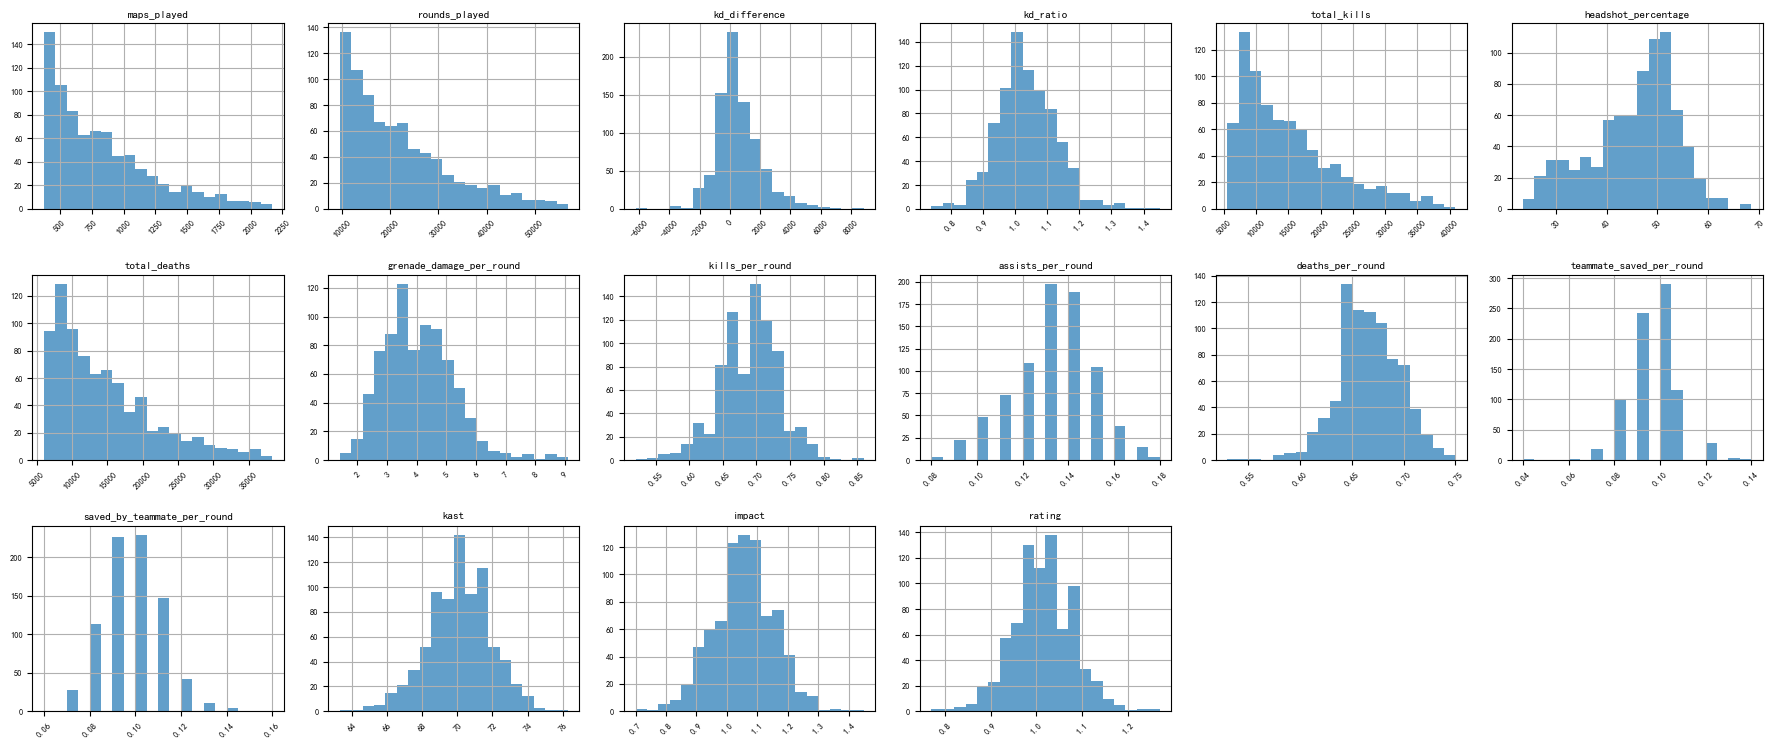

In [13]:
# 设置更大的图形尺寸和字体
plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6

# 创建直方图，设置更多的子图布局
fig, axes = plt.subplots(6, 6, figsize=(18, 15))
axes = axes.flatten()

# 为每个数值列创建直方图
for i, col in enumerate(df_numeric.columns):
    if i < len(axes):
        df_numeric[col].hist(ax=axes[i], bins=20, alpha=0.7)
        axes[i].set_title(col, fontsize=8, pad=5)
        axes[i].tick_params(axis='both', which='major', labelsize=6)
        axes[i].tick_params(axis='x', rotation=45)

# 隐藏多余的子图
for i in range(len(df_numeric.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=2.0)
plt.show()

### 根据数据相关性绘制热力图

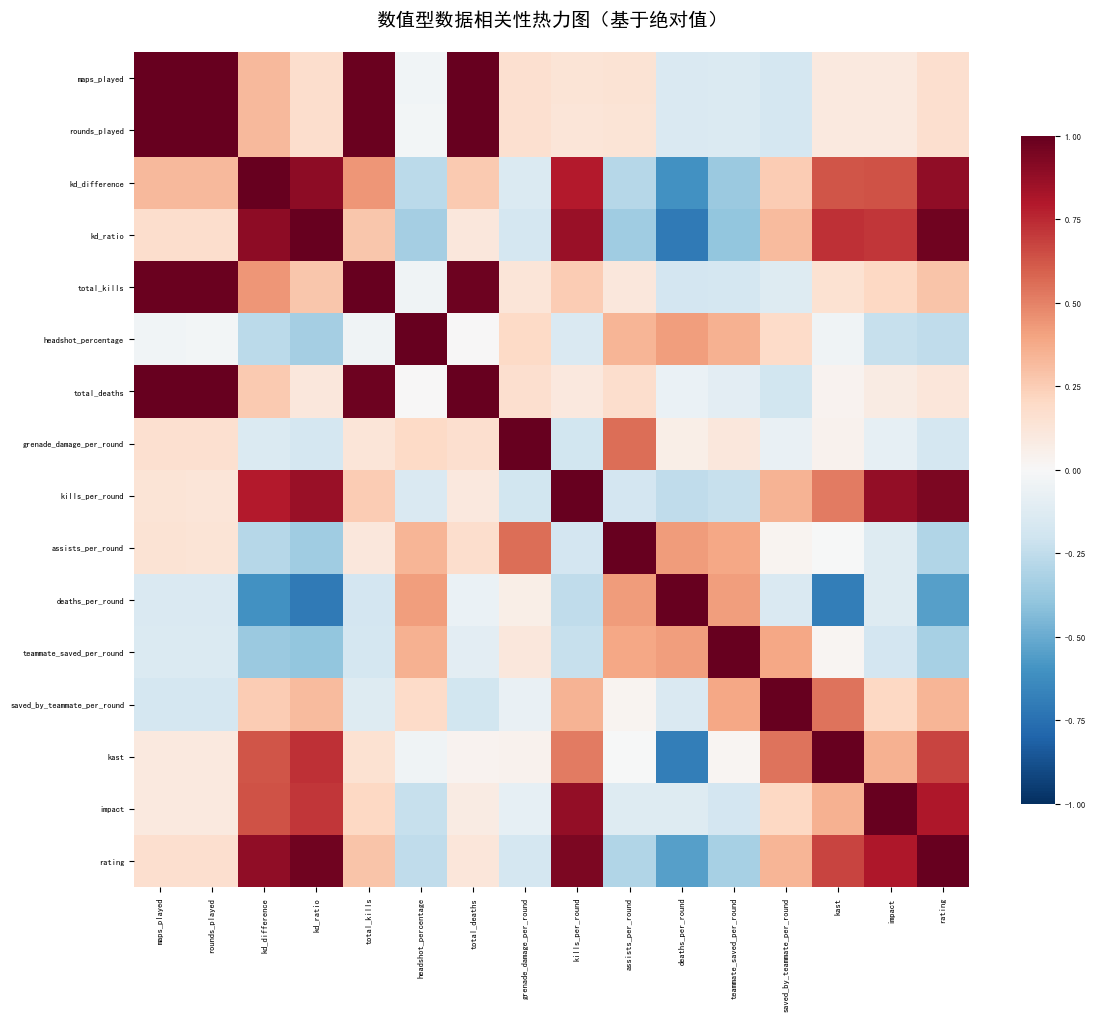

In [14]:
# 计算相关性矩阵
corr_matrix = df_numeric.corr()

# 使用绝对值相关性来设置颜色映射
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,  # 显示数值
            cmap='RdBu_r',  # 使用红蓝色彩映射
            center=0,  # 以0为中心
            vmin=-1, vmax=1,  # 设置颜色范围
            square=True,  # 正方形格子
            fmt='.2f',  # 数值格式
            cbar_kws={'shrink': 0.8})  # 调整颜色条大小

plt.title('数值型数据相关性热力图（基于绝对值）', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

相关矩阵显示，Rating（评分）与击杀死亡比（K/D 比）、击杀死亡差值（K/D Diff）、每回合击杀数（KPR）、每回合死亡数（DPR）、KAST（击杀 / 助攻 / 存活 / 补枪综合指标）以及 Impact（影响力）存在极强的关联性。

In [15]:
col_low_corr = []
for col in df_numeric.columns:
    if col != 'rating' and abs(df_numeric[col].corr(df_numeric['rating'])) < 0.05:
        col_low_corr.append(col)
print(col_low_corr)


[]


In [16]:
# 创建用于实验的新DataFrame，移除低相关性列
df_for_expr = df_numeric.drop(columns=col_low_corr)
print(f"原始数据形状: {df_numeric.shape}")
print(f"实验数据形状: {df_for_expr.shape}")
print(f"移除的列: {col_low_corr}")
df_for_expr.head(5)

原始数据形状: (801, 16)
实验数据形状: (801, 16)
移除的列: []


,maps_played,rounds_played,kd_difference,kd_ratio,total_kills,headshot_percentage,total_deaths,grenade_damage_per_round,kills_per_round,assists_per_round,deaths_per_round,teammate_saved_per_round,saved_by_teammate_per_round,kast,impact,rating
0,970,25491,5917,1.38,21602,41.3,15685,3.6,0.85,0.13,0.62,0.10,0.12,74.9,1.45,1.27
1,1532,40464,8864,1.34,34647,41.3,25783,2.4,0.86,0.10,0.64,0.08,0.11,74.2,1.36,1.25
2,847,22465,5361,1.45,17320,27.9,11959,3.9,0.77,0.11,0.53,0.08,0.11,76.3,1.21,1.23
3,378,10219,2225,1.37,8219,36.9,5994,3.3,0.80,0.10,0.59,0.09,0.11,74.5,1.21,1.22
4,829,21617,4118,1.32,16957,30.3,12839,2.9,0.78,0.11,0.59,0.08,0.10,73.7,1.24,1.20


### 散点矩阵

为了更直观显示数据间的相关性，我进一步绘制了散点矩阵。

In [17]:
numeric_cols = list(df_numeric.columns)
target_col = numeric_cols.pop()

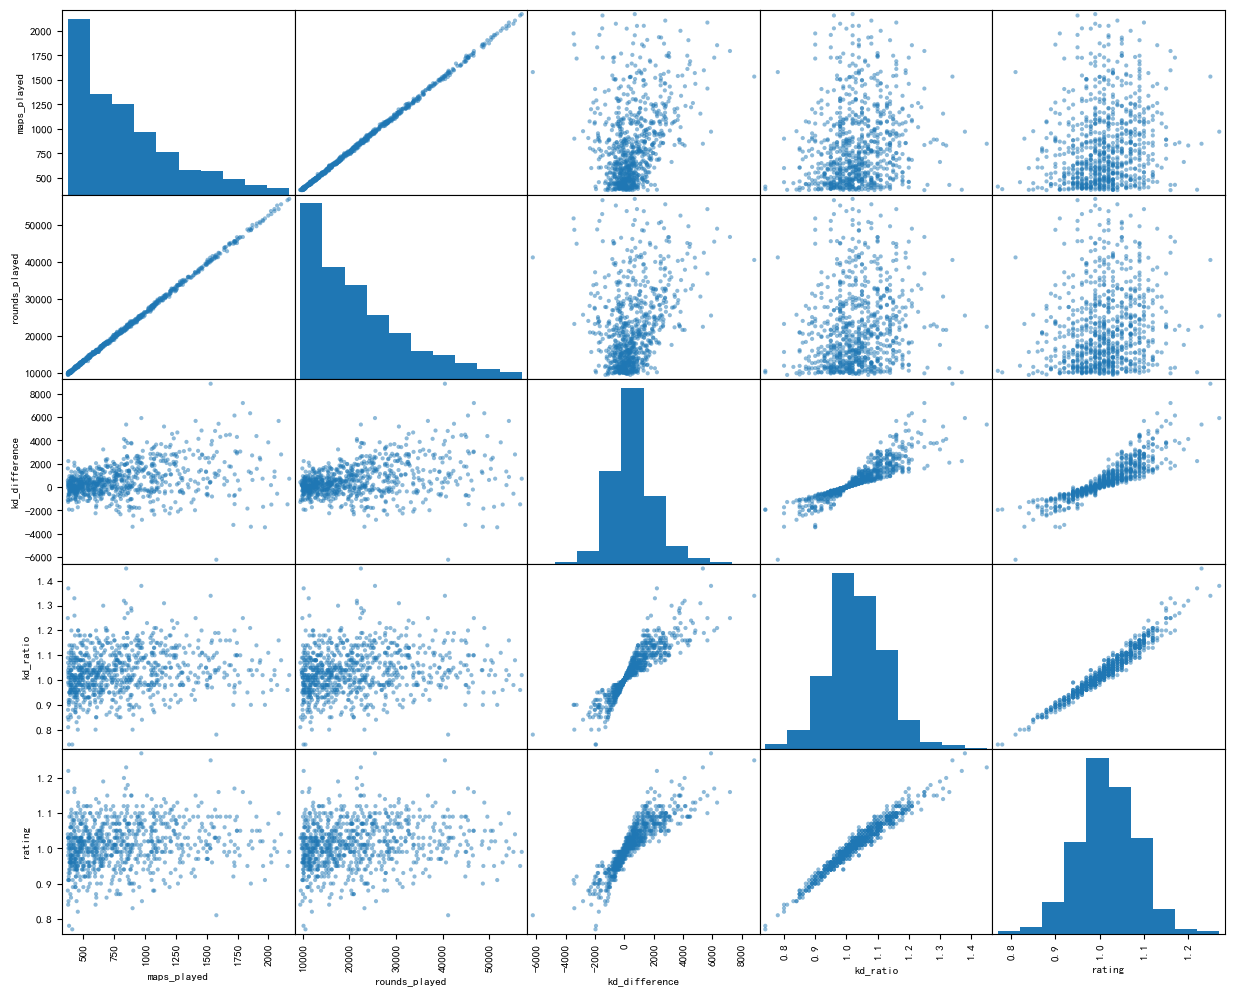

In [18]:
cols_to_plot = numeric_cols[:4] + [target_col]
scatter_matrix(df[cols_to_plot]);

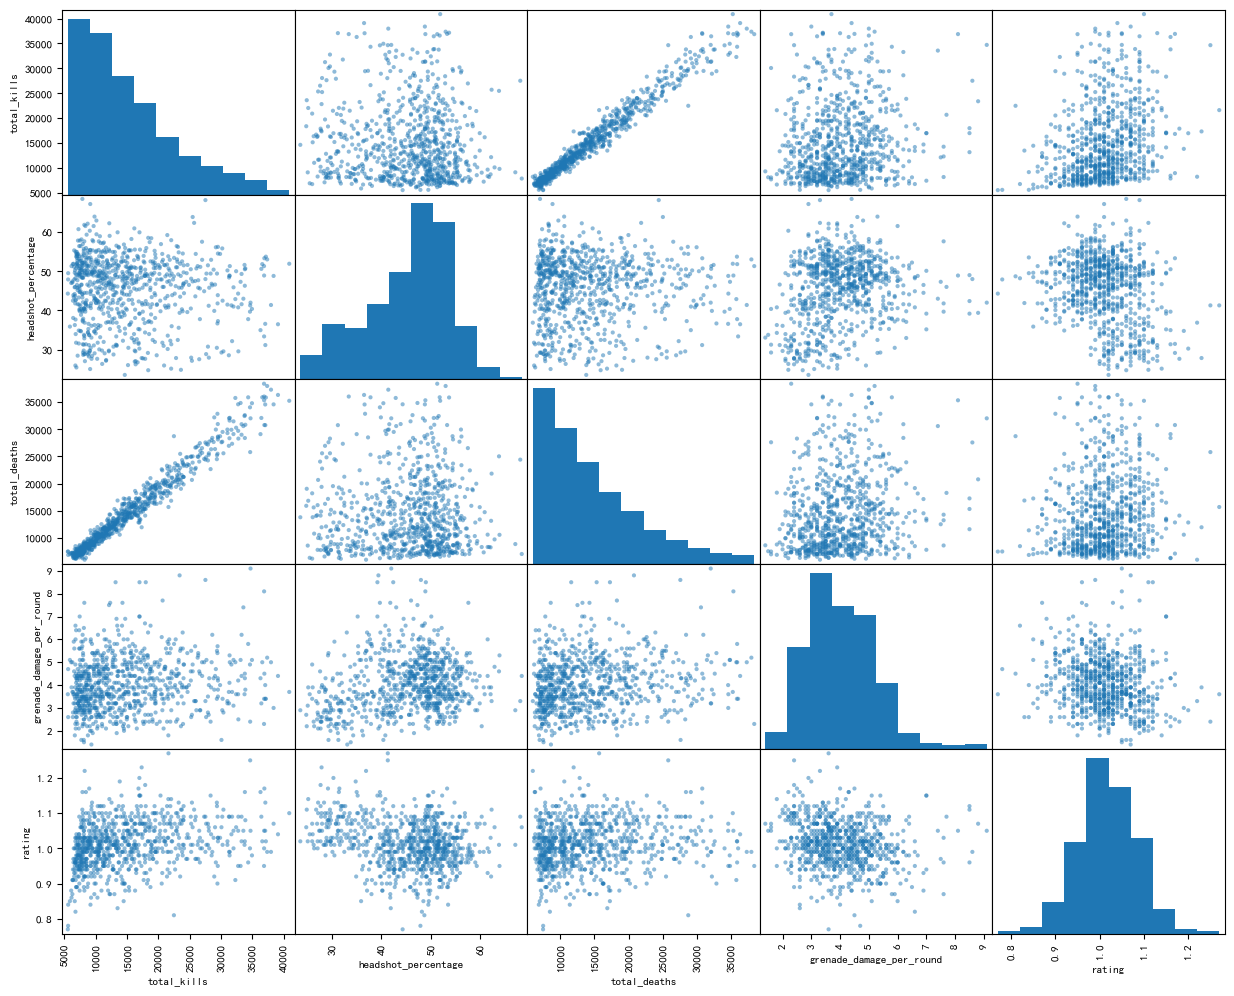

In [19]:
cols_to_plot = numeric_cols[4:8] + [target_col]
scatter_matrix(df[cols_to_plot]);

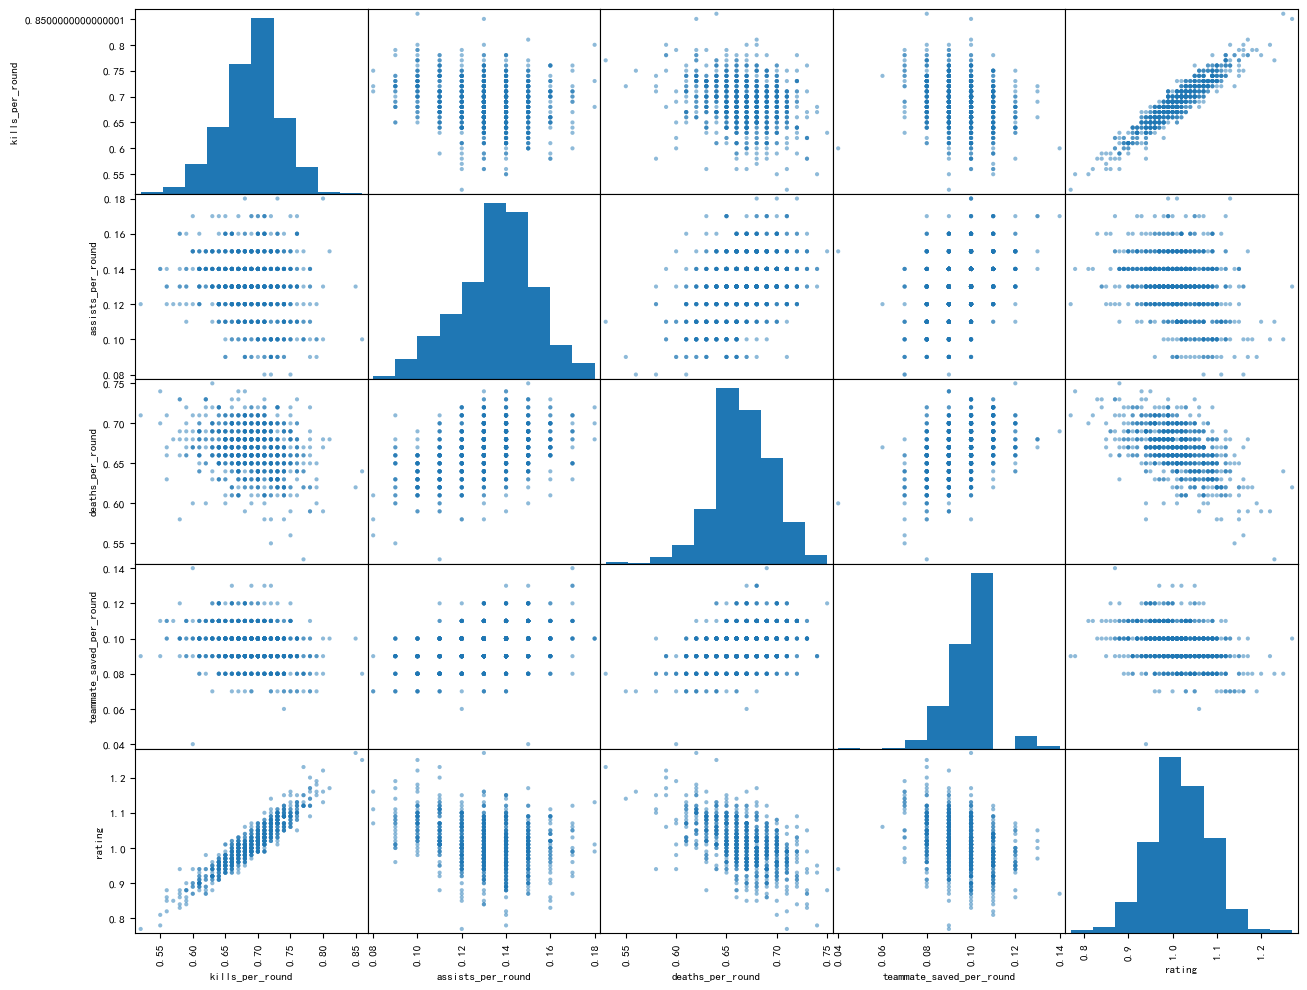

In [20]:
cols_to_plot = numeric_cols[8:12] + [target_col]
scatter_matrix(df[cols_to_plot]);

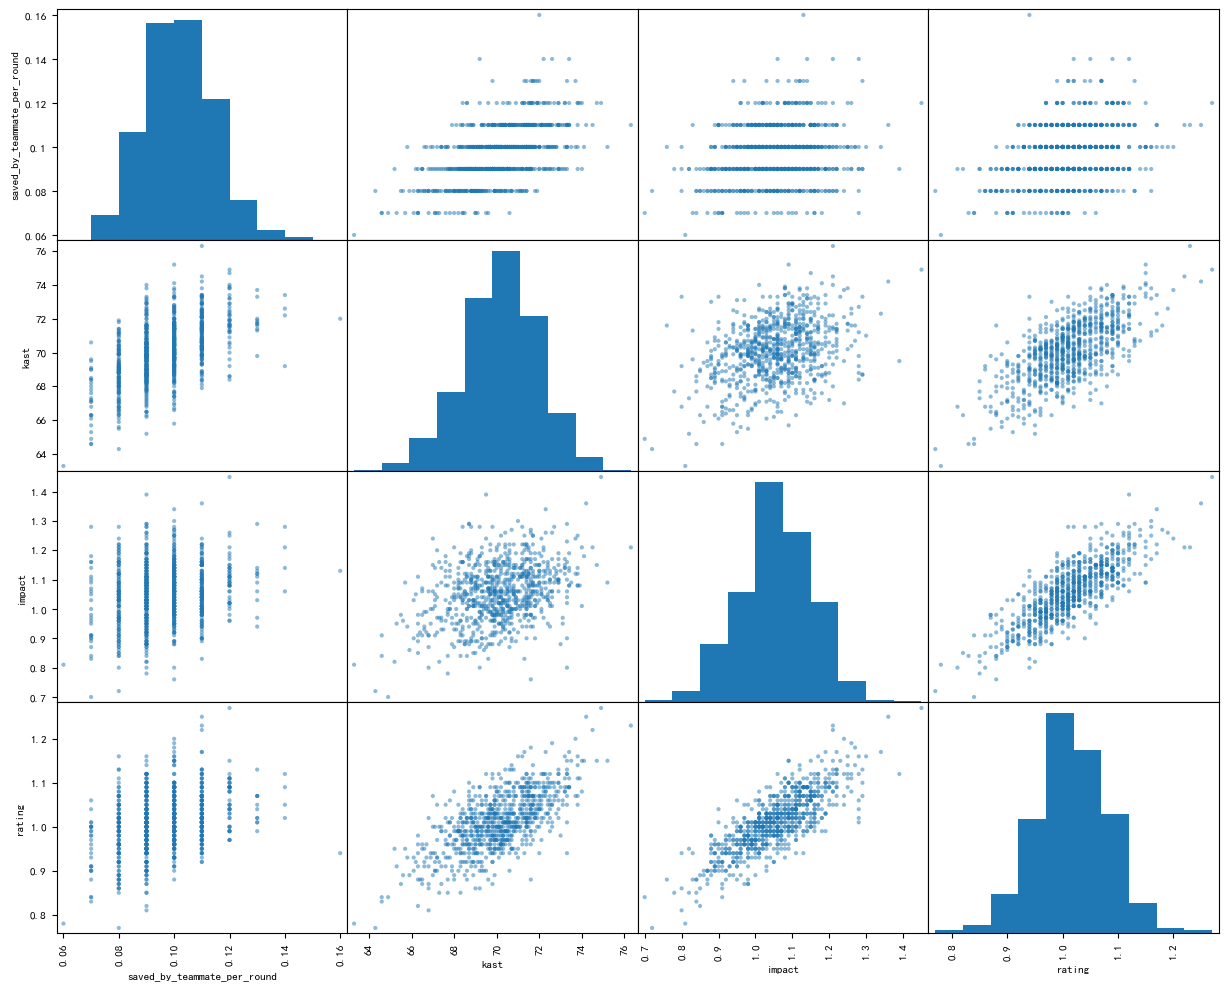

In [21]:
cols_to_plot = numeric_cols[12:] + [target_col]
scatter_matrix(df[cols_to_plot]);

从散点矩阵中我们可以得出：影响力（Impact）、击杀 / 助攻 / 存活 / 补枪综合指标（KAST）、每回合死亡数（Deaths per Round，简称 DPR）、击杀死亡差值（KD-Difference，简称 K/D Diff）以及击杀死亡比（KD-Ratio，简称 K/D 比），均是衡量选手评分（Rating）的优良指标。

在数值型数据中，我还将删除以下列：参赛地图数（maps_played）、参赛回合数（rounds_played）、总击杀数（total_kills）、总死亡数（total_deaths）、每回合被队友救回次数（saved_by_teammate_per_round）。删除这些列的原因是，如相关矩阵所示，它们与评分（Rating）几乎不存在相关性。

In [22]:
cols_to_drop = ['maps_played', 'rounds_played', 'total_kills', 'total_deaths', 'saved_by_teammate_per_round']
df_train = df_numeric.drop(columns = cols_to_drop)

## 模型搭建

我们将通过调用函数库和自己手写回归模型两种方式来搭建回归模型。

### 调用函数库


In [23]:
X, y = df_train.drop(columns = ['rating']), df_train['rating']

# 使用K折交叉验证进行更可靠的模型评估
kfold = KFold(n_splits=5, shuffle=True, random_state=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### Pipeline
我们采用Ridge/Lasso/ElasticNet三种回归模型，并使用Pipeline进行模型搭建。其中，我们还采用了StandardScaler进行数据标准化处理，并使用KFold进行K折交叉验证。

#### Ridge 回归模型

In [24]:
ridgePipe = Pipeline([
    ('stdscaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridgePipe.fit(X_train, y_train)

# 使用K折交叉验证评估模型性能
cv_scores = cross_val_score(ridgePipe, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
cv_r2_scores = cross_val_score(ridgePipe, X_train, y_train, cv=kfold, scoring='r2')

print('=== 原始模型性能 ===')
print(f'K折交叉验证 MSE: {-cv_scores.mean():} (+/- {cv_scores.std() * 2:})')
print(f'K折交叉验证 R²: {cv_r2_scores.mean():} (+/- {cv_r2_scores.std() * 2:})')
print(f'各折MSE分数: {-cv_scores}')
print(f'各折R²分数: {cv_r2_scores}')

print('\n' + '='*50)
print('开始随机搜索超参数优化...')
print('='*50)

# 随机搜索超参数优化
param_dist = {
    'ridge__alpha': loguniform(1e-3, 1e3),  # alpha从0.001到1000
}

# 创建随机搜索
random_search = RandomizedSearchCV(
    ridgePipe, 
    param_distributions=param_dist,
    n_iter=50,           # 随机采样50组参数
    cv=kfold,            # 使用您定义的kfold
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,           # 使用所有CPU核心
    return_train_score=True
)

# 执行随机搜索
random_search.fit(X_train, y_train)

print('\n=== 随机搜索结果 ===')
print(f'最佳参数: {random_search.best_params_}')
print(f'最佳交叉验证 MSE: {-random_search.best_score_:}')

# 使用最佳模型进行性能评估
best_model = random_search.best_estimator_

# 评估最佳模型的性能
best_cv_scores = cross_val_score(best_model, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
best_cv_r2_scores = cross_val_score(best_model, X_train, y_train, cv=kfold, scoring='r2')

print('\n=== 优化后模型性能 ===')
print(f'K折交叉验证 MSE: {-best_cv_scores.mean():} (+/- {best_cv_scores.std() * 2:})')
print(f'K折交叉验证 R²: {best_cv_r2_scores.mean():} (+/- {best_cv_r2_scores.std() * 2:})')
print(f'各折MSE分数: {-best_cv_scores}')
print(f'各折R²分数: {best_cv_r2_scores}')

=== 原始模型性能 ===
K折交叉验证 MSE: 2.9093658503061877e-05 (+/- 7.943421418304888e-07)
K折交叉验证 R²: 0.9932317941307783 (+/- 0.002347023164762845)
各折MSE分数: [2.92669720e-05 2.97078128e-05 2.89619718e-05 2.84926971e-05
 2.90388388e-05]
各折R²分数: [0.99222744 0.99237783 0.99524905 0.99388229 0.99242235]

开始随机搜索超参数优化...

=== 随机搜索结果 ===
最佳参数: {'ridge__alpha': 0.3905441275210791}
最佳交叉验证 MSE: 2.9069183067419235e-05

=== 优化后模型性能 ===
K折交叉验证 MSE: 2.9069183067419235e-05 (+/- 8.374129311737611e-07)
K折交叉验证 R²: 0.9932409114122844 (+/- 0.0023165044318786397)
各折MSE分数: [2.91500775e-05 2.95656249e-05 2.91988387e-05 2.82932846e-05
 2.91380896e-05]
各折R²分数: [0.99225849 0.99241431 0.99521019 0.99392511 0.99239645]


In [25]:
# 训练集评估
print("alpha=1.0")
predictions_on_train = ridgePipe.predict(X_train)
mse_train = mean_squared_error(y_train, predictions_on_train)
r2_train = r2_score(y_train, predictions_on_train)
print(f'训练集 MSE: {mse_train:}')
print(f'训练集 R²: {r2_train:}')

print("随机搜索alpha")
predictions_on_train1 = best_model.predict(X_train)
mse_train1 = mean_squared_error(y_train, predictions_on_train1)
r2_train1 = r2_score(y_train, predictions_on_train1)
print(f'训练集 MSE: {mse_train1:}')
print(f'训练集 R²: {r2_train1:}')

alpha=1.0
训练集 MSE: 2.7538948958254543e-05
训练集 R²: 0.9938413541054718
随机搜索alpha
训练集 MSE: 2.751252488712541e-05
训练集 R²: 0.9938472634267543


In [26]:
# 测试集评估
print("alpha=1.0")
predictions_on_test = ridgePipe.predict(X_test)
mse_test = mean_squared_error(y_test, predictions_on_test)
r2_test = r2_score(y_test, predictions_on_test)
print(f'测试集 MSE: {mse_test:}')
print(f'测试集 R²: {r2_test:}')

# 模型性能总结
print('\n=== 模型性能总结 ===')
print(f'K折交叉验证平均MSE: {-cv_scores.mean():}')
print(f'K折交叉验证平均R²: {cv_r2_scores.mean():}')
print(f'最终测试集MSE: {mse_test:}')
print(f'最终测试集R²: {r2_test:}')

print("\n随机搜索alpha")
predictions_on_test1 = best_model.predict(X_test)
mse_test1 = mean_squared_error(y_test, predictions_on_test1)
r2_test1 = r2_score(y_test, predictions_on_test1)
print(f'测试集 MSE: {mse_test1:}')
print(f'测试集 R²: {r2_test1:}')

# 模型性能总结
print('\n=== 模型性能总结 ===')
print(f'K折交叉验证平均MSE: {-best_cv_scores.mean():}')
print(f'K折交叉验证平均R²: {best_cv_r2_scores.mean():}')
print(f'最终测试集MSE: {mse_test:1}')
print(f'最终测试集R²: {r2_test1:}')

alpha=1.0
测试集 MSE: 3.2643628460701115e-05
测试集 R²: 0.9923503623116661

=== 模型性能总结 ===
K折交叉验证平均MSE: 2.9093658503061877e-05
K折交叉验证平均R²: 0.9932317941307783
最终测试集MSE: 3.2643628460701115e-05
最终测试集R²: 0.9923503623116661

随机搜索alpha
测试集 MSE: 3.275088522178581e-05
测试集 R²: 0.9923252279929456

=== 模型性能总结 ===
K折交叉验证平均MSE: 2.9069183067419235e-05
K折交叉验证平均R²: 0.9932409114122844
最终测试集MSE: 3.2643628460701115e-05
最终测试集R²: 0.9923252279929456


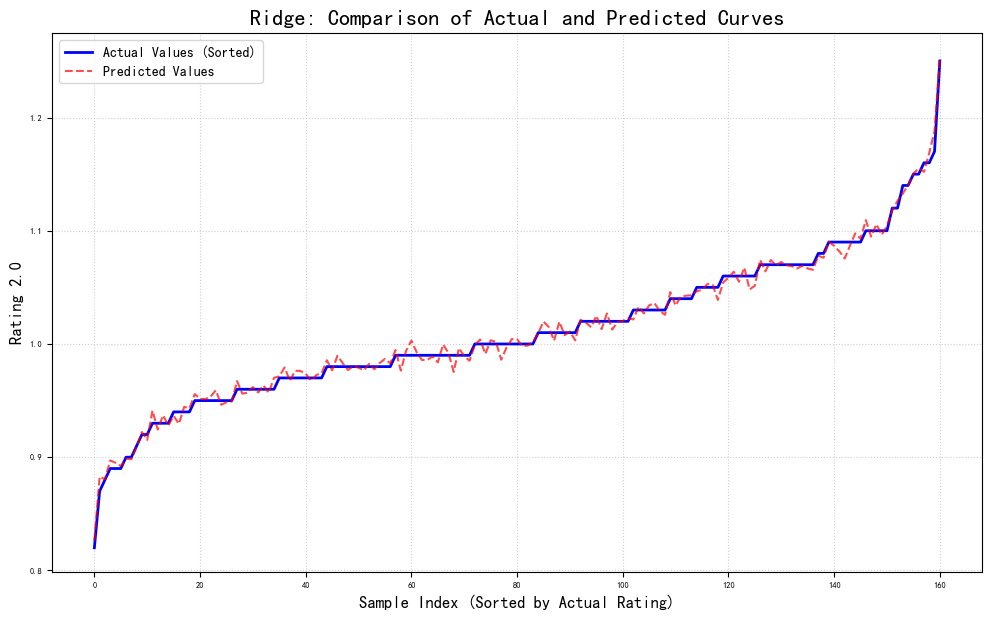

In [27]:
y_test_np = y_test.to_numpy()

# 为了绘制平滑的曲线，我们首先对真实值进行排序，并获取排序索引
sort_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sort_indices]
# predictions_on_test_lasso 本身是NumPy数组，可以直接使用位置索引
predictions_sorted = predictions_on_test1[sort_indices]

# 创建一个x轴，代表样本索引
x_axis = np.arange(len(y_test_np))

# 开始绘图
plt.figure(figsize=(12, 7))
plt.plot(x_axis, y_test_sorted, label='Actual Values (Sorted)', color='blue', linewidth=2)
plt.plot(x_axis, predictions_sorted, label='Predicted Values', color='red', linestyle='--', alpha=0.7)

# 添加图表元素
plt.title('Ridge: Comparison of Actual and Predicted Curves', fontsize=16)
plt.xlabel('Sample Index (Sorted by Actual Rating)', fontsize=12)
plt.ylabel('Rating 2.0', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Lasso 回归模型


In [28]:
lassoPipe = Pipeline([
    ('stdscaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, max_iter=10000))
])

lassoPipe.fit(X_train, y_train)

# 使用K折交叉验证评估模型性能
cv_scores_lasso = cross_val_score(lassoPipe, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
cv_r2_scores_lasso = cross_val_score(lassoPipe, X_train, y_train, cv=kfold, scoring='r2')

print('=== 原始Lasso模型性能 ===')
print(f'K折交叉验证 MSE: {-cv_scores_lasso.mean():} (+/- {cv_scores_lasso.std() * 2:})')
print(f'K折交叉验证 R²: {cv_r2_scores_lasso.mean():} (+/- {cv_r2_scores_lasso.std() * 2:})')
print(f'各折MSE分数: {-cv_scores_lasso}')
print(f'各折R²分数: {cv_r2_scores_lasso}')


# Lasso随机搜索超参数优化
param_dist_lasso = {
    'lasso__alpha': loguniform(5e-3, 1e2),  # Lasso的alpha范围通常更小
    'lasso__max_iter': [1000, 5000, 10000, 20000],
    'lasso__selection': ['cyclic', 'random'],
    'lasso__tol': [1e-4, 1e-5, 1e-6]
}

# 创建随机搜索
lasso_random_search = RandomizedSearchCV(
    lassoPipe, 
    param_distributions=param_dist_lasso,
    n_iter=50,           # 随机采样50组参数
    cv=kfold,            # 使用您定义的kfold
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,           # 使用所有CPU核心
    return_train_score=True
)

# 执行随机搜索
lasso_random_search.fit(X_train, y_train)

print('\n=== Lasso随机搜索结果 ===')
print(f'最佳参数: {lasso_random_search.best_params_}')
print(f'最佳交叉验证 MSE: {-lasso_random_search.best_score_:}')

# 使用最佳模型
best_lasso_model = lasso_random_search.best_estimator_

# 评估最佳模型的交叉验证性能
best_cv_scores_lasso = cross_val_score(best_lasso_model, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
best_cv_r2_scores_lasso = cross_val_score(best_lasso_model, X_train, y_train, cv=kfold, scoring='r2')

print('\n=== 优化后Lasso模型性能 ===')
print(f'K折交叉验证 MSE: {-best_cv_scores_lasso.mean():} (+/- {best_cv_scores_lasso.std() * 2:})')
print(f'K折交叉验证 R²: {best_cv_r2_scores_lasso.mean():} (+/- {best_cv_r2_scores_lasso.std() * 2:})')
print(f'各折MSE分数: {-best_cv_scores_lasso}')
print(f'各折R²分数: {best_cv_r2_scores_lasso}')


=== 原始Lasso模型性能 ===
K折交叉验证 MSE: 0.00014422659133185052 (+/- 4.237036829933759e-05)
K折交叉验证 R²: 0.9672294141999831 (+/- 0.005313972082396665)
各折MSE分数: [0.00012051 0.00014027 0.0001841  0.00013903 0.00013722]
各折R²分数: [0.96799565 0.96400969 0.96980015 0.97014808 0.96419349]

=== Lasso随机搜索结果 ===
最佳参数: {'lasso__alpha': 0.0058374430786217475, 'lasso__max_iter': 1000, 'lasso__selection': 'random', 'lasso__tol': 0.0001}
最佳交叉验证 MSE: 7.261620876038282e-05

=== 优化后Lasso模型性能 ===
K折交叉验证 MSE: 7.25462042723733e-05 (+/- 1.6385645967263576e-05)
K折交叉验证 R²: 0.9833453908103446 (+/- 0.004650066184681593)
各折MSE分数: [6.14223741e-05 7.48136294e-05 8.54055190e-05 6.64607986e-05
 7.46287003e-05]
各折R²分数: [0.98365073 0.98083094 0.98596311 0.98575616 0.98052601]


In [29]:
# 训练集评估
print("alpha=0.01")
predictions_on_train_lasso = lassoPipe.predict(X_train)
mse_train_lasso = mean_squared_error(y_train, predictions_on_train_lasso)
r2_train_lasso = r2_score(y_train, predictions_on_train_lasso)
print(f'训练集 MSE: {mse_train_lasso:}')
print(f'训练集 R²: {r2_train_lasso:}')

print("\n随机搜索alpha")
predictions_on_train_lasso1 = best_lasso_model.predict(X_train)
mse_train_lasso1 = mean_squared_error(y_train, predictions_on_train_lasso1)
r2_train_lasso1 = r2_score(y_train, predictions_on_train_lasso1)
print(f'训练集 MSE: {mse_train_lasso1:}')
print(f'训练集 R²: {r2_train_lasso1:}')

# 测试集评估
print("alpha=0.01")
predictions_on_test_lasso = lassoPipe.predict(X_test)
mse_test_lasso = mean_squared_error(y_test, predictions_on_test_lasso)
r2_test_lasso = r2_score(y_test, predictions_on_test_lasso)
print(f'测试集 MSE: {mse_test_lasso:}')
print(f'测试集 R²: {r2_test_lasso:}')

print("\n随机搜索alpha")
predictions_on_test_lasso1 = best_lasso_model.predict(X_test)
mse_test_lasso1 = mean_squared_error(y_test, predictions_on_test_lasso1)
r2_test_lasso1 = r2_score(y_test, predictions_on_test_lasso1)
print(f'测试集 MSE: {mse_test_lasso1:}')
print(f'测试集 R²: {r2_test_lasso1:}')

# 模型性能总结
print('\n=== Lasso 模型性能总结 ===')
print(f'K折交叉验证平均MSE: {-best_cv_scores_lasso.mean():}')
print(f'K折交叉验证平均R²: {best_cv_r2_scores_lasso.mean():}')
print(f'最终测试集MSE: {mse_test_lasso1:}')
print(f'最终测试集R²: {r2_test_lasso1:}')


alpha=0.01
训练集 MSE: 0.0001435960141787153
训练集 R²: 0.9678870459241953

随机搜索alpha
训练集 MSE: 7.254676913545427e-05
训练集 R²: 0.9837760742948242
alpha=0.01
测试集 MSE: 0.00014734013469493273
测试集 R²: 0.9654726297132243

随机搜索alpha
测试集 MSE: 7.81577692696643e-05
测试集 R²: 0.981684676439658

=== Lasso 模型性能总结 ===
K折交叉验证平均MSE: 7.25462042723733e-05
K折交叉验证平均R²: 0.9833453908103446
最终测试集MSE: 7.81577692696643e-05
最终测试集R²: 0.981684676439658


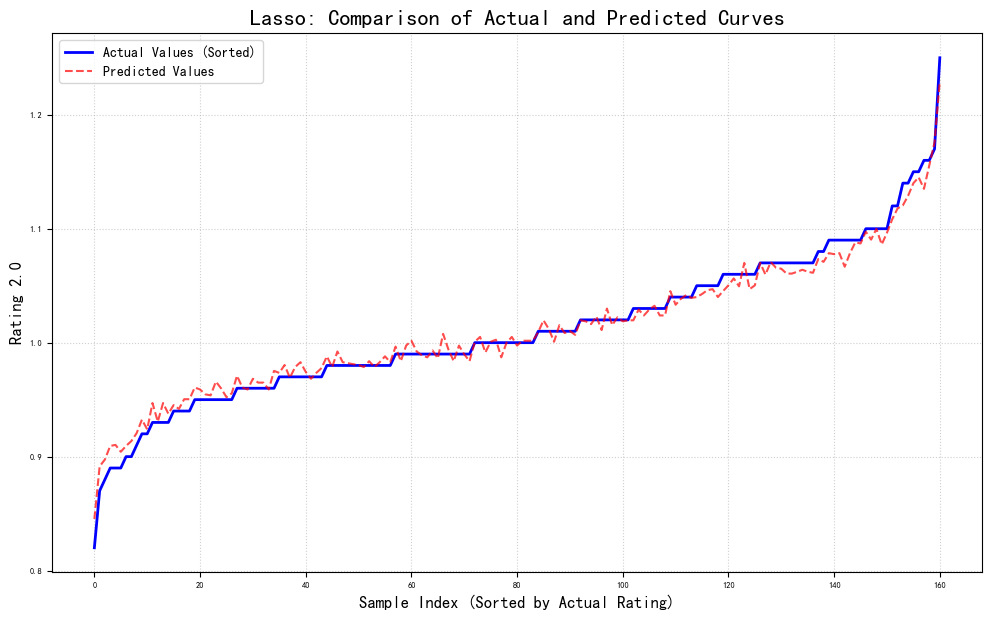

In [30]:
y_test_np = y_test.to_numpy()

# 为了绘制平滑的曲线，我们首先对真实值进行排序，并获取排序索引
sort_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sort_indices]
# predictions_on_test_lasso 本身是NumPy数组，可以直接使用位置索引
predictions_sorted = predictions_on_test_lasso1[sort_indices]

# 创建一个x轴，代表样本索引
x_axis = np.arange(len(y_test_np))

# 开始绘图
plt.figure(figsize=(12, 7))
plt.plot(x_axis, y_test_sorted, label='Actual Values (Sorted)', color='blue', linewidth=2)
plt.plot(x_axis, predictions_sorted, label='Predicted Values', color='red', linestyle='--', alpha=0.7)

# 添加图表元素
plt.title('Lasso: Comparison of Actual and Predicted Curves', fontsize=16)
plt.xlabel('Sample Index (Sorted by Actual Rating)', fontsize=12)
plt.ylabel('Rating 2.0', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Elastic Net 回归模型


In [31]:
elasticNetPipe = Pipeline([
    ('stdscaler', StandardScaler()),
    ('elasticnet', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))
])

elasticNetPipe.fit(X_train, y_train)

# 使用K折交叉验证评估模型性能
cv_scores_elastic = cross_val_score(elasticNetPipe, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
cv_r2_scores_elastic = cross_val_score(elasticNetPipe, X_train, y_train, cv=kfold, scoring='r2')

print('=== 原始 Elastic Net 模型性能 ===')
print(f'K折交叉验证 MSE: {-cv_scores_elastic.mean():} (+/- {cv_scores_elastic.std() * 2:})')
print(f'K折交叉验证 R²: {cv_r2_scores_elastic.mean():} (+/- {cv_r2_scores_elastic.std() * 2:})')
print(f'各折MSE分数: {-cv_scores_elastic}')
print(f'各折R²分数: {cv_r2_scores_elastic}')


param_dist_elastic_simple = {
    'elasticnet__alpha': loguniform(1e-2, 1e2),
    'elasticnet__l1_ratio': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],  # 0到1之间的均匀分布
    'elasticnet__max_iter': [10000, 20000]
}

elastic_random_search_simple = RandomizedSearchCV(
    elasticNetPipe, param_dist_elastic_simple, n_iter=40, cv=kfold,
    scoring='neg_mean_squared_error', random_state=42, n_jobs=-1
)
elastic_random_search_simple.fit(X_train, y_train)

print('\n=== 优化后Elastic Net模型性能 ===')
print(f'最佳参数: {elastic_random_search_simple.best_params_}')
print(f'最佳交叉验证 MSE: {-elastic_random_search_simple.best_score_:}')

# 最佳模型
best_elastic_simple = elastic_random_search_simple.best_estimator_

# 评估最佳模型的交叉验证性能
best_cv_scores_elastic = cross_val_score(best_elastic_simple, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
best_cv_r2_scores_elastic = cross_val_score(best_elastic_simple, X_train, y_train, cv=kfold, scoring='r2')


print(f'K折交叉验证 MSE: {-best_cv_scores_elastic.mean():} (+/- {best_cv_scores_elastic.std() * 2:})')
print(f'K折交叉验证 R²: {best_cv_r2_scores_elastic.mean():} (+/- {best_cv_r2_scores_elastic.std() * 2:})')
print(f'各折MSE分数: {-best_cv_scores_elastic}')
print(f'各折R²分数: {best_cv_r2_scores_elastic}')


=== 原始 Elastic Net 模型性能 ===
K折交叉验证 MSE: 6.449154135112548e-05 (+/- 1.435805189013217e-05)
K折交叉验证 R²: 0.9851663092431442 (+/- 0.004542525731599475)
各折MSE分数: [5.48265344e-05 6.71219624e-05 7.48184570e-05 5.80864013e-05
 6.76043516e-05]
各折R²分数: [0.98543948 0.98277843 0.98772671 0.98752819 0.98235874]

=== 优化后Elastic Net模型性能 ===
最佳参数: {'elasticnet__alpha': 0.012087541473056965, 'elasticnet__l1_ratio': 0.2, 'elasticnet__max_iter': 20000}
最佳交叉验证 MSE: 4.291462733583741e-05
K折交叉验证 MSE: 4.291462733583741e-05 (+/- 8.452321437145006e-06)
K折交叉验证 R²: 0.9900632866762209 (+/- 0.0036375442488405544)
各折MSE分数: [3.75827665e-05 4.56271296e-05 4.67321496e-05 3.79437901e-05
 4.66873009e-05]
各折R²分数: [0.99001898 0.98829339 0.99233401 0.99185304 0.98781701]


In [32]:
# 训练集评估
predictions_on_train_elastic = elasticNetPipe.predict(X_train)
mse_train_elastic = mean_squared_error(y_train, predictions_on_train_elastic)
r2_train_elastic = r2_score(y_train, predictions_on_train_elastic)
print(f'训练集 MSE: {mse_train_elastic}')
print(f'训练集 R²: {r2_train_elastic}')

predictions_on_train_elastic1 = best_elastic_simple.predict(X_train)
mse_train_elastic1 = mean_squared_error(y_train, predictions_on_train_elastic1)
r2_train_elastic1 = r2_score(y_train, predictions_on_train_elastic1)
print(f'训练集 MSE: {mse_train_elastic1}')
print(f'训练集 R²: {r2_train_elastic1}')

# 测试集评估
predictions_on_test_elastic = elasticNetPipe.predict(X_test)
mse_test_elastic = mean_squared_error(y_test, predictions_on_test_elastic)
r2_test_elastic = r2_score(y_test, predictions_on_test_elastic)
print(f'\n测试集 MSE: {mse_test_elastic}')
print(f'测试集 R²: {r2_test_elastic}')

predictions_on_test_elastic1 = best_elastic_simple.predict(X_test)
mse_test_elastic1 = mean_squared_error(y_test, predictions_on_test_elastic1)
r2_test_elastic1 = r2_score(y_test, predictions_on_test_elastic1)
print(f'\n测试集 MSE: {mse_test_elastic1}')
print(f'测试集 R²: {r2_test_elastic1}')

# 模型性能总结
print('\n=== Elastic Net 模型性能总结 ===')
print(f'K折交叉验证平均MSE: {-best_cv_scores_elastic.mean()}')
print(f'K折交叉验证平均R²: {best_cv_r2_scores_elastic.mean()}')
print(f'最终测试集MSE: {mse_test_elastic1:}')
print(f'最终测试集R²: {r2_test_elastic1:}')


训练集 MSE: 6.439206124674645e-05
训练集 R²: 0.9855997444115013
训练集 MSE: 4.218437987844888e-05
训练集 R²: 0.9905661374969158

测试集 MSE: 7.019241316394622e-05
测试集 R²: 0.9835512608587478

测试集 MSE: 4.732051382327838e-05
测试集 R²: 0.9889110125607004

=== Elastic Net 模型性能总结 ===
K折交叉验证平均MSE: 4.291462733583741e-05
K折交叉验证平均R²: 0.9900632866762209
最终测试集MSE: 4.732051382327838e-05
最终测试集R²: 0.9889110125607004


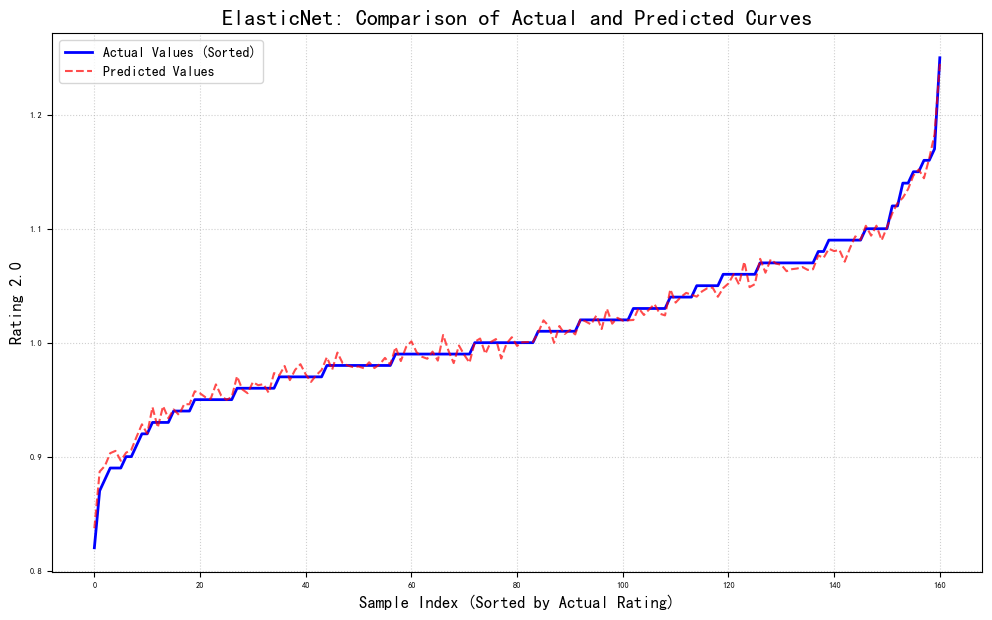

In [33]:
y_test_np = y_test.to_numpy()

# 为了绘制平滑的曲线，我们首先对真实值进行排序，并获取排序索引
sort_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sort_indices]
# predictions_on_test_elastic 本身是NumPy数组，可以直接使用位置索引
predictions_sorted = predictions_on_test_elastic1[sort_indices]

# 创建一个x轴，代表样本索引
x_axis = np.arange(len(y_test_np))

# 开始绘图
plt.figure(figsize=(12, 7))
plt.plot(x_axis, y_test_sorted, label='Actual Values (Sorted)', color='blue', linewidth=2)
plt.plot(x_axis, predictions_sorted, label='Predicted Values', color='red', linestyle='--', alpha=0.7)

# 添加图表元素
plt.title('ElasticNet: Comparison of Actual and Predicted Curves', fontsize=16)
plt.xlabel('Sample Index (Sorted by Actual Rating)', fontsize=12)
plt.ylabel('Rating 2.0', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 模型对比


In [34]:
# 创建模型对比表格
model_comparison = pd.DataFrame({
    '模型': ['Ridge', 'Lasso', 'Elastic Net'],
    '正则化参数': ['alpha=1.0', 'alpha=0.01', 'alpha=0.01, l1_ratio=0.5'],
    'K折交叉验证 MSE': [
        f'{-best_cv_scores.mean():.8f}',
        f'{-best_cv_scores_lasso.mean():.8f}',
        f'{-best_cv_scores_elastic.mean():.8f}'
    ],
    'K折交叉验证 R²': [
        f'{best_cv_r2_scores.mean():}',
        f'{best_cv_r2_scores_lasso.mean():}',
        f'{best_cv_r2_scores_elastic.mean():}'
    ],
    '测试集 MSE': [
        f'{mse_test1:.8f}',
        f'{mse_test_lasso1:.8f}',
        f'{mse_test_elastic1:.8f}'
    ],
    '测试集 R²': [
        f'{r2_test1:}',
        f'{r2_test_lasso1:}',
        f'{r2_test_elastic1:}'
    ]
})

print('\n============ 三种模型性能对比 ============')

styled_table = model_comparison.style.set_table_styles([
    {'selector': 'thead th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#F2F2F2')]},
    {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', 'white')]},
    {'selector': 'td, th', 'props': [('padding', '8px'), ('text-align', 'center')]}
]).set_properties(**{'border': '1px solid black'})

display(styled_table)




============ 三种模型性能对比 ============


,模型,正则化参数,K折交叉验证 MSE,K折交叉验证 R²,测试集 MSE,测试集 R²
0,Ridge,alpha=1.0,0.00002907,0.9932409114122844,0.00003275,0.9923252279929456
1,Lasso,alpha=0.01,0.00007255,0.9833453908103446,0.00007816,0.981684676439658
2,Elastic Net,"alpha=0.01, l1_ratio=0.5",0.00004291,0.9900632866762209,0.00004732,0.9889110125607004


### 分析特征重要性

Ridge回归最重要的特征:


,特征,系数,绝对系数
4,kills_per_round,0.032744,0.032744
1,kd_ratio,0.028076,0.028076
6,deaths_per_round,-0.008632,0.008632
9,impact,0.003962,0.003962
2,headshot_percentage,0.002316,0.002316



Lasso回归最重要的特征:


,特征,系数,绝对系数
1,kd_ratio,0.037336,0.037336
4,kills_per_round,0.020919,0.020919
0,kd_difference,0.000000,0.000000
2,headshot_percentage,-0.000000,0.000000
3,grenade_damage_per_round,-0.000000,0.000000



ElasticNet回归最重要的特征:


,特征,系数,绝对系数
1,kd_ratio,0.039681,0.039681
4,kills_per_round,0.023801,0.023801
0,kd_difference,0.000000,0.000000
2,headshot_percentage,-0.000000,0.000000
3,grenade_damage_per_round,-0.000000,0.000000


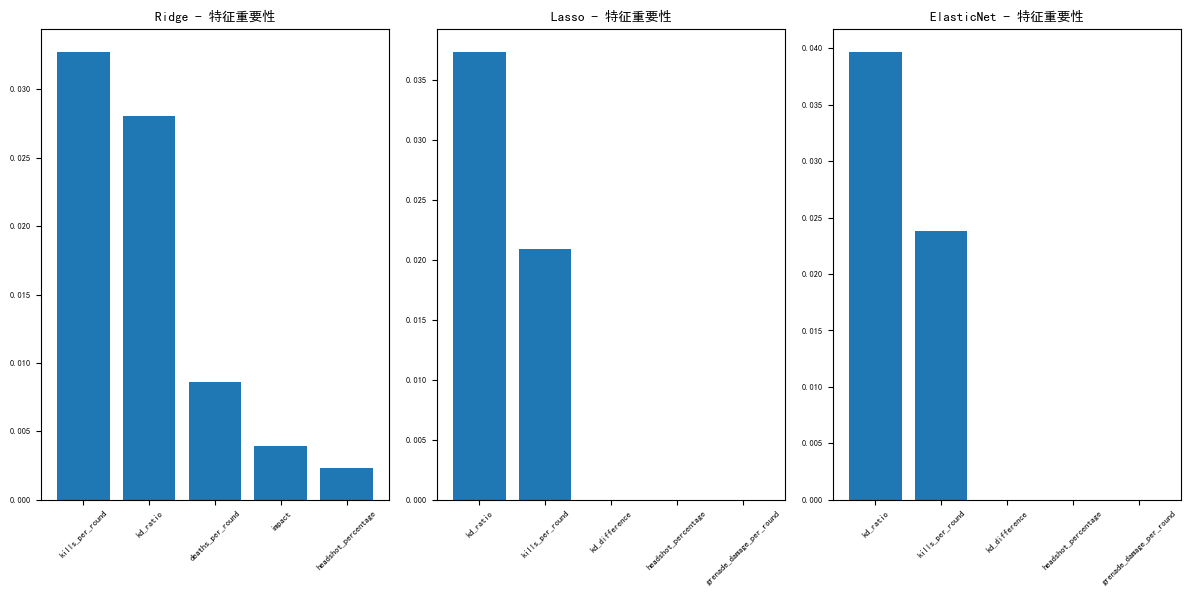

In [35]:
def analyze_feature_importance(model, feature_names, top_k=5):
    """分析特征重要性
    
    参数:
        model: 已训练的模型(需要有coef_属性)
        feature_names: 特征名列表
        top_k: 返回前k个最重要的特征
    """
    # 获取特征系数
    coef = model.coef_
    # 创建特征重要性数据框
    importance_df = pd.DataFrame({
        '特征': feature_names,
        '系数': coef,
        '绝对系数': np.abs(coef)
    })
    # 按绝对系数大小排序
    importance_df = importance_df.sort_values('绝对系数', ascending=False)
    
    return importance_df.head(top_k)

# 获取特征名
feature_names = X_train.columns.tolist()

# 分析三种模型的特征重要性
print("Ridge回归最重要的特征:")
ridge_importance = analyze_feature_importance(ridgePipe.named_steps['ridge'], feature_names)
display(ridge_importance)

print("\nLasso回归最重要的特征:")
lasso_importance = analyze_feature_importance(lassoPipe.named_steps['lasso'], feature_names)
display(lasso_importance)

print("\nElasticNet回归最重要的特征:")
elastic_importance = analyze_feature_importance(elasticNetPipe.named_steps['elasticnet'], feature_names)
display(elastic_importance)

# 可视化特征重要性
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.bar(ridge_importance['特征'], ridge_importance['绝对系数'])
plt.title('Ridge - 特征重要性')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
plt.bar(lasso_importance['特征'], lasso_importance['绝对系数'])
plt.title('Lasso - 特征重要性')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
plt.bar(elastic_importance['特征'], elastic_importance['绝对系数'])
plt.title('ElasticNet - 特征重要性')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 加权MSE

In [36]:
def weighted_mse(y_true: np.ndarray, y_pred: np.ndarray, weights: str = 'normalized') -> float:
    """计算加权均方误差
    
    参数:
        y_true: 真实值
        y_pred: 预测值  
        weights: 权重方案
            - 'relative': 相对误差(误差/真实值)的平方
            - 'normalized': 先对真实值和预测值分别标准化，再计算MSE
    """
    if weights == 'relative':
        # 相对误差的平方和的平均
        return np.mean(np.square((y_true - y_pred) / y_true))
    elif weights == 'normalized':
        # 先标准化再计算MSE
        y_true_norm = (y_true - y_true.mean()) / y_true.std()
        y_pred_norm = (y_pred - y_true.mean()) / y_true.std()  # 使用y_true的统计量
        return np.mean(np.square(y_true_norm - y_pred_norm))
    else:
        raise ValueError("weights must be 'relative' or 'normalized'")

# 对三种模型都进行加权MSE评估
models = {
    'Ridge': (predictions_on_train1, predictions_on_test1),
    'Lasso': (predictions_on_train_lasso1, predictions_on_test_lasso1),
    'ElasticNet': (predictions_on_train_elastic1, predictions_on_test_elastic1)
}

print("\n=== 所有模型的加权MSE对比 ===")
results = []
for name, (train_pred, test_pred) in models.items():
    results.append({
        '模型': name,
        '训练集相对WMSE': f"{weighted_mse(y_train, train_pred, 'relative'):.8f}",
        '训练集归一化WMSE': f"{weighted_mse(y_train, train_pred, 'normalized'):.8f}",
        '测试集相对WMSE': f"{weighted_mse(y_test, test_pred, 'relative'):.8f}",
        '测试集归一化WMSE': f"{weighted_mse(y_test, test_pred, 'normalized'):.8f}"
    })

wmse_comparison = pd.DataFrame(results)
styled_wmse = wmse_comparison.style.set_table_styles([
    {'selector': 'thead th', 'props': [('background-color', '#4BACC6'), ('color', 'white')]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#F2F2F2')]},
    {'selector': 'td, th', 'props': [('padding', '8px'), ('text-align', 'center')]}
]).set_properties(**{'border': '1px solid black'})

display(styled_wmse)


=== 所有模型的加权MSE对比 ===


,模型,训练集相对WMSE,训练集归一化WMSE,测试集相对WMSE,测试集归一化WMSE
0,Ridge,0.00002723,0.00614312,0.00003204,0.00762710
1,Lasso,0.00007701,0.01619858,0.00007980,0.01820156
2,ElasticNet,0.00004411,0.00941912,0.00004823,0.01102011


### 模型性能分析

从上面的对比结果可以看出：

**性能排序：Ridge > Elastic Net > Lasso**

#### 1. Ridge回归表现最佳的原因
- **L2正则化特性**：对所有特征系数进行收缩，但不会将系数压缩到0
- **保留所有特征**：在CSGO数据集中，所有特征都与rating有相关性，Ridge保留了所有有用信息
- **稳定性好**：L2正则化对异常值不敏感，模型更稳定
- **适合高相关性数据**：当特征间存在多重共线性时，Ridge表现更好

#### 2. Lasso回归表现最差的原因
- **L1正则化特性**：会将不重要的特征系数压缩到0，进行特征选择
- **过度稀疏化**：在CSGO数据集中，可能将一些有用但相关性不是最强的特征系数设为0
- **信息丢失**：CSGO选手的rating预测需要综合考虑多个指标，Lasso可能过度简化了模型

#### 3. Elastic Net表现中等的原因
- **平衡机制**：结合了L1和L2正则化的优点
- **特征选择+系数收缩**：既进行特征选择，又保持模型稳定性
- **l1_ratio=0.5**：L1和L2正则化各占50%，在特征选择和系数收缩间取得平衡
- **性能介于两者之间**：比Lasso保留更多信息，但比Ridge更简洁


## 手写Ridge/Lasso/ElasticNet回归模型

### 手写Ridge回归模型

In [37]:
import numpy as np
from typing import Optional, Tuple

class StandardScalerManual:
    def __init__(self):
        self.mean_: Optional[np.ndarray] = None
        self.scale_: Optional[np.ndarray] = None

    def fit(self, X: np.ndarray) -> "StandardScalerManual":
        self.mean_ = X.mean(axis=0)
        # 避免除以0
        std = X.std(axis=0, ddof=0)
        std[std == 0] = 1.0
        self.scale_ = std
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (X - self.mean_) / self.scale_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

class RidgeManual:
    """手写 Ridge 回归
    支持两种求解：
    - closed_form=True: 闭式解 (X^T X + alpha I)^{-1} X^T y
    - closed_form=False: 批量梯度下降
    注意：会在内部进行标准化（仅对特征），并单独学习偏置项。
    """
    def __init__(self, alpha: float = 1.0, closed_form: bool = False, lr: float = 1e-2, max_iter: int = 10_000, tol: float = 1e-7, random_state: int = 2):
        self.alpha = alpha
        self.closed_form = closed_form
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.scaler_: Optional[StandardScalerManual] = None
        self.coef_: Optional[np.ndarray] = None  # 形状: (n_features,)
        self.intercept_: float = 0.0

    def _prepare(self, X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        self.scaler_ = StandardScalerManual().fit(X)
        Xs = self.scaler_.transform(X)
        y = y.astype(float)
        return Xs, y

    def fit(self, X: np.ndarray, y: np.ndarray) -> "RidgeManual":
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        Xs, y = self._prepare(X, y)
        n_samples, n_features = Xs.shape

        if self.closed_form:
            # 闭式解：在特征空间做 L2 正则，不惩罚偏置项
            A = Xs.T @ Xs + self.alpha * np.eye(n_features)
            b = Xs.T @ y
            w = np.linalg.solve(A, b)
            self.coef_ = w
            # 单独拟合偏置：y - Xs w 的均值
            self.intercept_ = float(y.mean() - Xs.mean(axis=0) @ w)
        else:
            rng = np.random.RandomState(self.random_state)
            w = rng.randn(n_features) * 0.01
            b = 0.0
            prev_loss = np.inf
            for _ in range(self.max_iter):
                y_pred = Xs @ w + b
                residual = y_pred - y
                # MSE + L2 正则（不惩罚偏置）
                grad_w = (Xs.T @ residual) / n_samples + self.alpha * w
                grad_b = residual.mean()
                w -= self.lr * grad_w
                b -= self.lr * grad_b
                loss = (residual @ residual) / (2 * n_samples) + 0.5 * self.alpha * (w @ w)
                if abs(prev_loss - loss) < self.tol:
                    break
                prev_loss = loss
            self.coef_ = w
            self.intercept_ = float(b)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        Xs = self.scaler_.transform(X)
        return Xs @ self.coef_ + self.intercept_

# 将训练/测试数据转为 numpy 供手写模型使用
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values


print("闭式解 Ridge 回归:")
ridge_manual = RidgeManual(alpha=0.3905441275210791, closed_form=True)
ridge_manual.fit(X_train_np, y_train_np)

# 训练/测试评估
from sklearn.metrics import mean_squared_error, r2_score
pred_train_rm = ridge_manual.predict(X_train_np)
pred_test_rm = ridge_manual.predict(X_test_np)

print(f"\n训练集 MSE: {mean_squared_error(y_train_np, pred_train_rm):.8f}")
print(f"训练集 R²: {r2_score(y_train_np, pred_train_rm):}")
print(f"测试集 MSE: {mean_squared_error(y_test_np, pred_test_rm):.8f}")
print(f"测试集 R²: {r2_score(y_test_np, pred_test_rm):}")

# 批量梯度下降 Ridge 回归 (主要用于对比)
print("批量梯度下降 Ridge 回归")
ridge_manual_gd = RidgeManual(alpha=0.3905441275210791, closed_form=False)
ridge_manual_gd.fit(X_train_np, y_train_np)

pred_train_gd = ridge_manual_gd.predict(X_train_np)
pred_test_gd = ridge_manual_gd.predict(X_test_np)

# 训练集评估
mse_train_gd = mean_squared_error(y_train_np, pred_train_gd)
r2_train_gd = r2_score(y_train_np, pred_train_gd)
mse_test_gd = mean_squared_error(y_test_np, pred_test_gd)
r2_test_gd = r2_score(y_test_np, pred_test_gd)
print(f"\n训练集 MSE: {mse_train_gd:.8f}")
print(f"训练集 R²: {r2_train_gd:}")
print(f"测试集 MSE: {mse_test_gd:.8f}")
print(f"测试集 R²: {r2_test_gd:}")

# 比较两种方法的系数差异
coef_diff = np.abs(ridge_manual.coef_ - ridge_manual_gd.coef_)
print(f"\n闭式解与梯度下降系数最大差异: {coef_diff.max():.8f}")



闭式解 Ridge 回归:

训练集 MSE: 0.00002751
训练集 R²: 0.9938472634267544
测试集 MSE: 0.00003275
测试集 R²: 0.9923252279929479
批量梯度下降 Ridge 回归

训练集 MSE: 0.00012306
训练集 R²: 0.9724790262244442
测试集 MSE: 0.00010531
测试集 R²: 0.9753228448222904

闭式解与梯度下降系数最大差异: 0.01592215


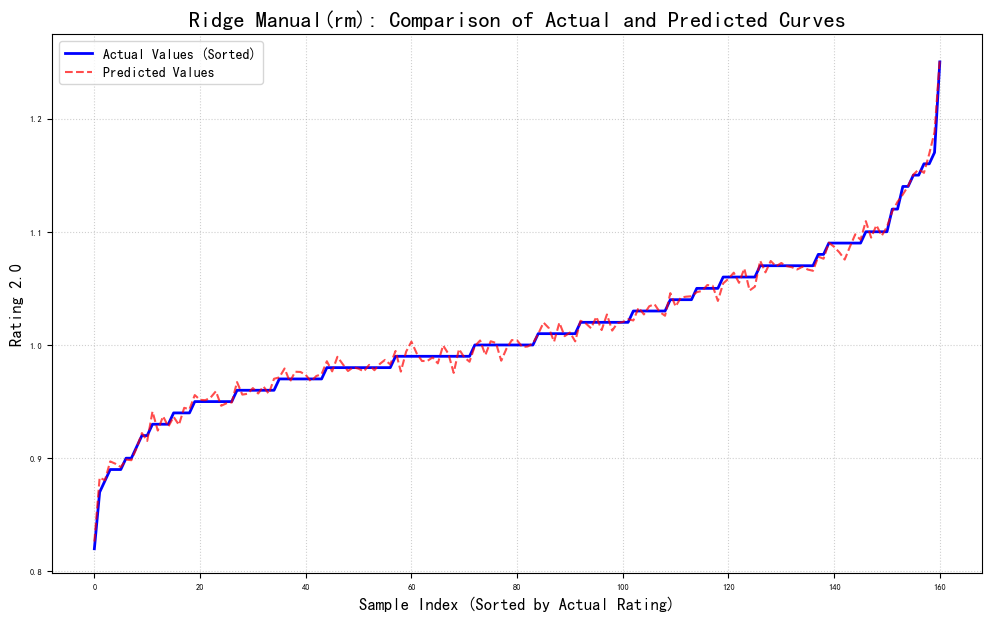

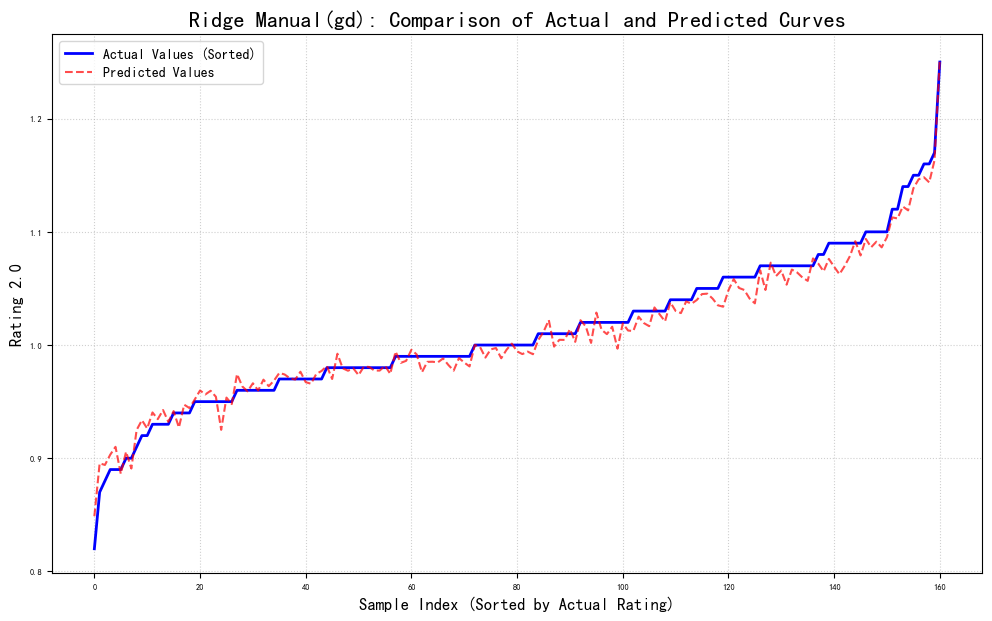

In [38]:
y_test_np = y_test.to_numpy()

# 为了绘制平滑的曲线，我们首先对真实值进行排序，并获取排序索引
sort_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sort_indices]
# predictions_on_test_lasso 本身是NumPy数组，可以直接使用位置索引
predictions_sorted = pred_test_rm[sort_indices]

# 创建一个x轴，代表样本索引
x_axis = np.arange(len(y_test_np))

# 开始绘图
plt.figure(figsize=(12, 7))
plt.plot(x_axis, y_test_sorted, label='Actual Values (Sorted)', color='blue', linewidth=2)
plt.plot(x_axis, predictions_sorted, label='Predicted Values', color='red', linestyle='--', alpha=0.7)

# 添加图表元素
plt.title('Ridge Manual(rm): Comparison of Actual and Predicted Curves', fontsize=16)
plt.xlabel('Sample Index (Sorted by Actual Rating)', fontsize=12)
plt.ylabel('Rating 2.0', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

y_test_np = y_test.to_numpy()

# 为了绘制平滑的曲线，我们首先对真实值进行排序，并获取排序索引
sort_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sort_indices]
# predictions_on_test_lasso 本身是NumPy数组，可以直接使用位置索引
predictions_sorted = pred_test_gd[sort_indices]

# 创建一个x轴，代表样本索引
x_axis = np.arange(len(y_test_np))

# 开始绘图
plt.figure(figsize=(12, 7))
plt.plot(x_axis, y_test_sorted, label='Actual Values (Sorted)', color='blue', linewidth=2)
plt.plot(x_axis, predictions_sorted, label='Predicted Values', color='red', linestyle='--', alpha=0.7)

# 添加图表元素
plt.title('Ridge Manual(gd): Comparison of Actual and Predicted Curves', fontsize=16)
plt.xlabel('Sample Index (Sorted by Actual Rating)', fontsize=12)
plt.ylabel('Rating 2.0', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 手写Lasso回归模型

In [39]:
class LassoManual:
    """手写 Lasso 回归（坐标下降法）
    - 内部对特征做标准化，不惩罚偏置项
    - 目标： (1/2n)||y - Xw - b||^2 + alpha * ||w||_1
    采用常见的坐标下降更新：
      w_j <- S( (1/n) * x_j^T (y - (y_pred - x_j * w_j)), alpha )
    其中 S 为 soft-thresholding：S(z, a) = sign(z) * max(|z|-a, 0)
    注意：这里 alpha 与 sklearn 的 alpha 量纲略有差异，调参时可与其同量级尝试。
    """
    def __init__(self, alpha: float = 1.0, max_iter: int = 10_000, tol: float = 1e-4, random_state: int = 2):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.scaler_: Optional[StandardScalerManual] = None
        self.coef_: Optional[np.ndarray] = None
        self.intercept_: float = 0.0

    @staticmethod
    def _soft_threshold(z: float, lam: float) -> float:
        if z > lam:
            return z - lam
        elif z < -lam:
            return z + lam
        else:
            return 0.0

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LassoManual":
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self.scaler_ = StandardScalerManual().fit(X)
        Xs = self.scaler_.transform(X)
        n_samples, n_features = Xs.shape

        # 初始化
        w = np.zeros(n_features, dtype=float)
        b = y.mean()  # 初始化偏置为均值

        prev_obj = np.inf
        for _ in range(self.max_iter):
            # 更新偏置项（不惩罚）
            y_pred = Xs @ w + b
            b = b - (y_pred - y).mean()

            # 逐坐标更新 w_j
            for j in range(n_features):
                # 计算去掉第 j 列的残差 r = y - (sum_{k!=j} x_k w_k + b)
                r = y - (y_pred - Xs[:, j] * w[j])
                # 内积与平方范数
                rho = (Xs[:, j] @ r) / n_samples
                # 列的平方均值，用于标准化步长（对标准化后的 X，约为1）
                z = (Xs[:, j] @ Xs[:, j]) / n_samples
                if z == 0:
                    continue
                w_j_new = self._soft_threshold(rho, self.alpha) / z
                if w_j_new != w[j]:
                    # 更新预测缓存
                    y_pred += Xs[:, j] * (w_j_new - w[j])
                    w[j] = w_j_new

            # 计算目标函数
            residual = y - (Xs @ w + b)
            obj = 0.5 * (residual @ residual) / n_samples + self.alpha * np.abs(w).sum()
            if abs(prev_obj - obj) < self.tol:
                break
            prev_obj = obj

        self.coef_ = w
        self.intercept_ = float(b)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        Xs = self.scaler_.transform(X)
        return Xs @ self.coef_ + self.intercept_

lasso_manual = LassoManual(alpha=0.0058374430786217475, max_iter=10000, tol=1e-7)
lasso_manual.fit(X_train_np, y_train_np)

pred_train_lm = lasso_manual.predict(X_train_np)
pred_test_lm = lasso_manual.predict(X_test_np)
print(f"[Lasso 手写] 训练集 MSE: {mean_squared_error(y_train_np, pred_train_lm):.8f}")
print(f"[Lasso 手写] 训练集 R²: {r2_score(y_train_np, pred_train_lm):}")
print(f"[Lasso 手写] 测试集 MSE: {mean_squared_error(y_test_np, pred_test_lm):.8f}")
print(f"[Lasso 手写] 测试集 R²: {r2_score(y_test_np, pred_test_lm):}")


[Lasso 手写] 训练集 MSE: 0.00007122
[Lasso 手写] 训练集 R²: 0.9840727101420335
[Lasso 手写] 测试集 MSE: 0.00007641
[Lasso 手写] 测试集 R²: 0.9820947907926226


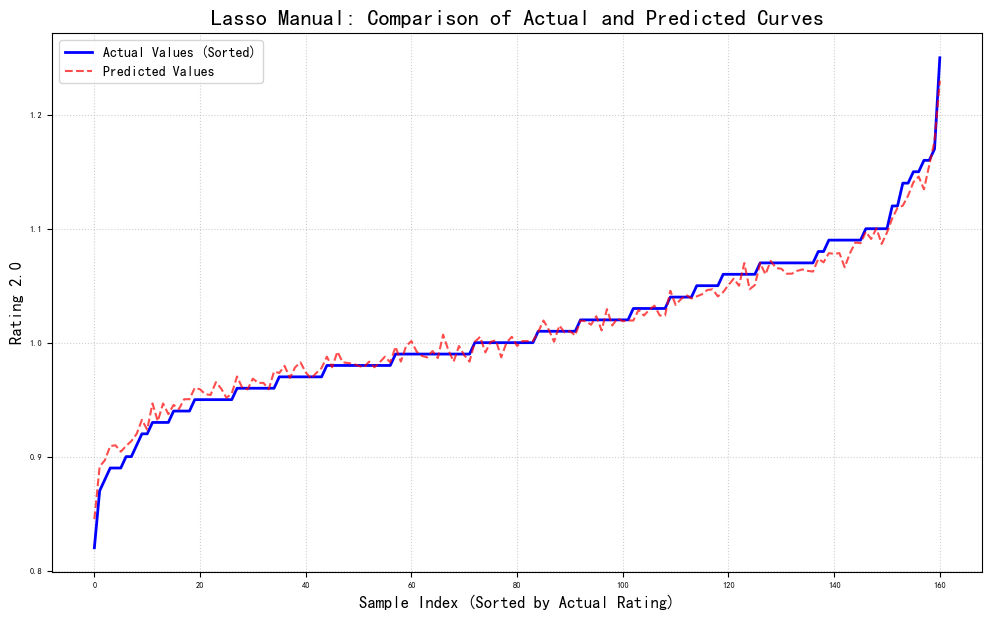

In [40]:
y_test_np = y_test.to_numpy()

# 为了绘制平滑的曲线，我们首先对真实值进行排序，并获取排序索引
sort_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sort_indices]
# pred_test_lm 本身是NumPy数组，可以直接使用位置索引
predictions_sorted = pred_test_lm[sort_indices]

# 创建一个x轴，代表样本索引
x_axis = np.arange(len(y_test_np))

# 开始绘图
plt.figure(figsize=(12, 7))
plt.plot(x_axis, y_test_sorted, label='Actual Values (Sorted)', color='blue', linewidth=2)
plt.plot(x_axis, predictions_sorted, label='Predicted Values', color='red', linestyle='--', alpha=0.7)

# 添加图表元素
plt.title('Lasso Manual: Comparison of Actual and Predicted Curves', fontsize=16)
plt.xlabel('Sample Index (Sorted by Actual Rating)', fontsize=12)
plt.ylabel('Rating 2.0', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 手写ElasticNet回归模型

In [41]:
class ElasticNetManual:
    """手写 Elastic Net 回归（坐标下降法）
    目标： (1/2n)||y - Xw - b||^2 + alpha * [ l1_ratio * ||w||_1 + (1-l1_ratio) * 0.5 * ||w||_2^2 ]
    更新：
      w_j <- S(rho_j, alpha * l1_ratio) / (z_j + alpha * (1 - l1_ratio))
    其中 rho_j = (1/n) x_j^T (y - (y_pred - x_j w_j))，z_j = (1/n) ||x_j||^2
    """
    def __init__(self, alpha: float = 0.01, l1_ratio: float = 0.5, max_iter: int = 10_000, tol: float = 1e-6):
        assert 0.0 <= l1_ratio <= 1.0
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.max_iter = max_iter
        self.tol = tol

        self.scaler_: Optional[StandardScalerManual] = None
        self.coef_: Optional[np.ndarray] = None
        self.intercept_: float = 0.0

    @staticmethod
    def _soft_threshold(z: float, lam: float) -> float:
        if z > lam:
            return z - lam
        elif z < -lam:
            return z + lam
        else:
            return 0.0

    def fit(self, X: np.ndarray, y: np.ndarray) -> "ElasticNetManual":
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self.scaler_ = StandardScalerManual().fit(X)
        Xs = self.scaler_.transform(X)
        n_samples, n_features = Xs.shape

        w = np.zeros(n_features, dtype=float)
        b = y.mean()

        prev_obj = np.inf
        for _ in range(self.max_iter):
            y_pred = Xs @ w + b
            b = b - (y_pred - y).mean()

            for j in range(n_features):
                r = y - (y_pred - Xs[:, j] * w[j])
                rho = (Xs[:, j] @ r) / n_samples
                z = (Xs[:, j] @ Xs[:, j]) / n_samples
                if z == 0:
                    continue
                denom = z + self.alpha * (1.0 - self.l1_ratio)
                w_j_new = self._soft_threshold(rho, self.alpha * self.l1_ratio) / denom
                if w_j_new != w[j]:
                    y_pred += Xs[:, j] * (w_j_new - w[j])
                    w[j] = w_j_new

            residual = y - (Xs @ w + b)
            obj = 0.5 * (residual @ residual) / n_samples \
                  + self.alpha * (self.l1_ratio * np.abs(w).sum() + (1.0 - self.l1_ratio) * 0.5 * (w @ w))
            if abs(prev_obj - obj) < self.tol:
                break
            prev_obj = obj

        self.coef_ = w
        self.intercept_ = float(b)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        Xs = self.scaler_.transform(X)
        return Xs @ self.coef_ + self.intercept_

enet_manual = ElasticNetManual(alpha=0.012087541473056965, l1_ratio=0.2, max_iter=20000, tol=1e-7)
enet_manual.fit(X_train_np, y_train_np)

pred_train_em = enet_manual.predict(X_train_np)
pred_test_em = enet_manual.predict(X_test_np)
print(f"[ElasticNet 手写] 训练集 MSE: {mean_squared_error(y_train_np, pred_train_em):.8f}")
print(f"[ElasticNet 手写] 训练集 R²: {r2_score(y_train_np, pred_train_em):}")
print(f"[ElasticNet 手写] 测试集 MSE: {mean_squared_error(y_test_np, pred_test_em):.8f}")
print(f"[ElasticNet 手写] 测试集 R²: {r2_score(y_test_np, pred_test_em):}")


[ElasticNet 手写] 训练集 MSE: 0.00004244
[ElasticNet 手写] 训练集 R²: 0.9905086361343274
[ElasticNet 手写] 测试集 MSE: 0.00004709
[ElasticNet 手写] 测试集 R²: 0.9889646782568249


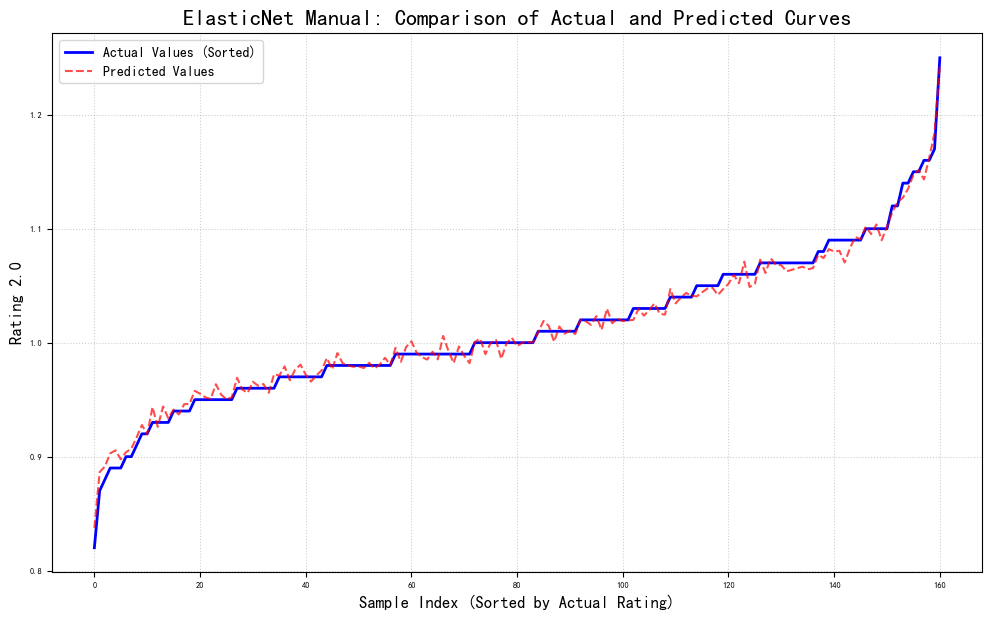

In [42]:
y_test_np = y_test.to_numpy()

# 为了绘制平滑的曲线，我们首先对真实值进行排序，并获取排序索引
sort_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sort_indices]
# pred_test_em 本身是NumPy数组，可以直接使用位置索引
predictions_sorted = pred_test_em[sort_indices]

# 创建一个x轴，代表样本索引
x_axis = np.arange(len(y_test_np))

# 开始绘图
plt.figure(figsize=(12, 7))
plt.plot(x_axis, y_test_sorted, label='Actual Values (Sorted)', color='blue', linewidth=2)
plt.plot(x_axis, predictions_sorted, label='Predicted Values', color='red', linestyle='--', alpha=0.7)

# 添加图表元素
plt.title('ElasticNet Manual: Comparison of Actual and Predicted Curves', fontsize=16)
plt.xlabel('Sample Index (Sorted by Actual Rating)', fontsize=12)
plt.ylabel('Rating 2.0', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 使用K折交叉验证评估手写模型性能

In [43]:
# 手写模型的 K 折交叉验证与评估
from sklearn.model_selection import KFold

def kfold_eval_manual(model_ctor, ctor_kwargs, X_np, y_np, n_splits=5, random_state=2):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    mse_list, r2_list = [] , []
    for train_idx, valid_idx in kf.split(X_np):
        X_tr, X_va = X_np[train_idx], X_np[valid_idx]
        y_tr, y_va = y_np[train_idx], y_np[valid_idx]
        model = model_ctor(**ctor_kwargs)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        mse_list.append(mean_squared_error(y_va, pred))
        r2_list.append(r2_score(y_va, pred))
    return float(np.mean(mse_list)), float(np.std(mse_list)), float(np.mean(r2_list)), float(np.std(r2_list))

# Ridge
ridge_cv_mse_mean, ridge_cv_mse_std, ridge_cv_r2_mean, ridge_cv_r2_std = kfold_eval_manual(
    RidgeManual, {"alpha":0.3905441275210791, "closed_form":True}, X_train_np, y_train_np, n_splits=5, random_state=2
)
print(f"[Ridge 手写|CV] MSE: {ridge_cv_mse_mean:.8f} (+/- {2*ridge_cv_mse_std:.8f})  R²: {ridge_cv_r2_mean:} (+/- {2*ridge_cv_r2_std:})")

# Lasso
lasso_cv_mse_mean, lasso_cv_mse_std, lasso_cv_r2_mean, lasso_cv_r2_std = kfold_eval_manual(
    LassoManual, {"alpha":0.0058374430786217475, "max_iter":10000, "tol":1e-7}, X_train_np, y_train_np, n_splits=5, random_state=2
)
print(f"[Lasso 手写|CV] MSE: {lasso_cv_mse_mean:.8f} (+/- {2*lasso_cv_mse_std:.8f})  R²: {lasso_cv_r2_mean:} (+/- {2*lasso_cv_r2_std:})")

# Elastic Net
enet_cv_mse_mean, enet_cv_mse_std, enet_cv_r2_mean, enet_cv_r2_std = kfold_eval_manual(
    ElasticNetManual, {"alpha":0.012087541473056965, "l1_ratio":0.2, "max_iter":20000, "tol":1e-7}, X_train_np, y_train_np, n_splits=5, random_state=2
)
print(f"[ElasticNet 手写|CV] MSE: {enet_cv_mse_mean:.8f} (+/- {2*enet_cv_mse_std:.8f})  R²: {enet_cv_r2_mean:} (+/- {2*enet_cv_r2_std:})")


[Ridge 手写|CV] MSE: 0.00002907 (+/- 0.00000084)  R²: 0.9932409114122767 (+/- 0.002316504431863642)
[Lasso 手写|CV] MSE: 0.00007142 (+/- 0.00001573)  R²: 0.98360323683599 (+/- 0.004546661332708135)
[ElasticNet 手写|CV] MSE: 0.00004309 (+/- 0.00000757)  R²: 0.9900209265234171 (+/- 0.0035330011123701046)


In [44]:
# 手写模型性能对比汇总
manual_cmp = pd.DataFrame({
    '模型': ['Ridge(手写)', 'Lasso(手写)', 'ElasticNet(手写)'],
    'K折交叉验证 MSE': [
        f'{ridge_cv_mse_mean:.8f}',
        f'{lasso_cv_mse_mean:.8f}',
        f'{enet_cv_mse_mean:.8f}'
    ],
    'K折交叉验证 R²': [
        f'{ridge_cv_r2_mean:}',
        f'{lasso_cv_r2_mean:}',
        f'{enet_cv_r2_mean:}'
    ],
    '测试集 MSE': [
        f'{mean_squared_error(y_test_np, pred_test_rm):.8f}',
        f'{mean_squared_error(y_test_np, pred_test_lm):.8f}',
        f'{mean_squared_error(y_test_np, pred_test_em):.8f}'
    ],
    '测试集 R²': [
        f'{r2_score(y_test_np, pred_test_rm):}',
        f'{r2_score(y_test_np, pred_test_lm):}',
        f'{r2_score(y_test_np, pred_test_em):}'
    ]
})

print('\n============ 手写三种模型性能对比 ============')
styled_manual = manual_cmp.style.set_table_styles([
    {'selector': 'thead th', 'props': [('background-color', '#9BBB59'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#F7F7F7')]},
    {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', 'white')]},
    {'selector': 'td, th', 'props': [('padding', '8px'), ('text-align', 'center')]}
]).set_properties(**{'border': '1px solid black'})

display(styled_manual)



============ 手写三种模型性能对比 ============


,模型,K折交叉验证 MSE,K折交叉验证 R²,测试集 MSE,测试集 R²
0,Ridge(手写),0.00002907,0.9932409114122767,0.00003275,0.9923252279929479
1,Lasso(手写),0.00007142,0.98360323683599,0.00007641,0.9820947907926226
2,ElasticNet(手写),0.00004309,0.9900209265234171,0.00004709,0.9889646782568249


## 手写 vs 调库 模型统一对比（以测试集 R² 为主）

In [45]:
rows = []

# 计算所有模型的加权MSE
def get_weighted_mse(y_true, y_pred):
    return {
        'relative': weighted_mse(y_true, y_pred, 'relative'),
        'normalized': weighted_mse(y_true, y_pred, 'normalized')
    }

# Ridge
ridge_train_wmse = get_weighted_mse(y_train, predictions_on_train1)
ridge_test_wmse = get_weighted_mse(y_test, predictions_on_test1)
ridge_manual_train_wmse = get_weighted_mse(y_train_np, pred_train_rm)
ridge_manual_test_wmse = get_weighted_mse(y_test_np, pred_test_rm)

rows.extend([
    {
        '模型': 'Ridge(调库)',
        'CV MSE': float(-best_cv_scores.mean()),
        'CV R²': float(best_cv_r2_scores.mean()),
        '测试集 MSE': float(mse_test1),
        '测试集 R²': float(r2_test1),
        '训练集相对WMSE': f"{ridge_train_wmse['relative']:.8f}",
        '测试集相对WMSE': f"{ridge_test_wmse['relative']:.8f}",
        '训练集归一化WMSE': f"{ridge_train_wmse['normalized']:.8f}",
        '测试集归一化WMSE': f"{ridge_test_wmse['normalized']:.8f}"
    },
    {
        '模型': 'Ridge(手写)',
        'CV MSE': float(ridge_cv_mse_mean),
        'CV R²': float(ridge_cv_r2_mean),
        '测试集 MSE': float(mean_squared_error(y_test_np, pred_test_rm)),
        '测试集 R²': float(r2_score(y_test_np, pred_test_rm)),
        '训练集相对WMSE': f"{ridge_manual_train_wmse['relative']:.8f}",
        '测试集相对WMSE': f"{ridge_manual_test_wmse['relative']:.8f}",
        '训练集归一化WMSE': f"{ridge_manual_train_wmse['normalized']:.8f}",
        '测试集归一化WMSE': f"{ridge_manual_test_wmse['normalized']:.8f}"
    }
])

# Lasso
lasso_train_wmse = get_weighted_mse(y_train, predictions_on_train_lasso1)
lasso_test_wmse = get_weighted_mse(y_test, predictions_on_test_lasso1)
lasso_manual_train_wmse = get_weighted_mse(y_train_np, pred_train_lm)
lasso_manual_test_wmse = get_weighted_mse(y_test_np, pred_test_lm)

rows.extend([
    {
        '模型': 'Lasso(调库)',
        'CV MSE': float(-best_cv_scores_lasso.mean()),
        'CV R²': float(best_cv_r2_scores_lasso.mean()),
        '测试集 MSE': float(mse_test_lasso1),
        '测试集 R²': float(r2_test_lasso1),
        '训练集相对WMSE': f"{lasso_train_wmse['relative']:.8f}",
        '测试集相对WMSE': f"{lasso_test_wmse['relative']:.8f}",
        '训练集归一化WMSE': f"{lasso_train_wmse['normalized']:.8f}",
        '测试集归一化WMSE': f"{lasso_test_wmse['normalized']:.8f}"
    },
    {
        '模型': 'Lasso(手写)',
        'CV MSE': float(lasso_cv_mse_mean),
        'CV R²': float(lasso_cv_r2_mean),
        '测试集 MSE': float(mean_squared_error(y_test_np, pred_test_lm)),
        '测试集 R²': float(r2_score(y_test_np, pred_test_lm)),
        '训练集相对WMSE': f"{lasso_manual_train_wmse['relative']:.8f}",
        '测试集相对WMSE': f"{lasso_manual_test_wmse['relative']:.8f}",
        '训练集归一化WMSE': f"{lasso_manual_train_wmse['normalized']:.8f}",
        '测试集归一化WMSE': f"{lasso_manual_test_wmse['normalized']:.8f}"
    }
])

# Elastic Net
enet_train_wmse = get_weighted_mse(y_train, predictions_on_train_elastic1)
enet_test_wmse = get_weighted_mse(y_test, predictions_on_test_elastic1)
enet_manual_train_wmse = get_weighted_mse(y_train_np, pred_train_em)
enet_manual_test_wmse = get_weighted_mse(y_test_np, pred_test_em)

rows.extend([
    {
        '模型': 'ElasticNet(调库)',
        'CV MSE': float(-best_cv_scores_elastic.mean()),
        'CV R²': float(best_cv_r2_scores_elastic.mean()),
        '测试集 MSE': float(mse_test_elastic1),
        '测试集 R²': float(r2_test_elastic1),
        '训练集相对WMSE': f"{enet_train_wmse['relative']:.8f}",
        '测试集相对WMSE': f"{enet_test_wmse['relative']:.8f}",
        '训练集归一化WMSE': f"{enet_train_wmse['normalized']:.8f}",
        '测试集归一化WMSE': f"{enet_test_wmse['normalized']:.8f}"
    },
    {
        '模型': 'ElasticNet(手写)',
        'CV MSE': float(enet_cv_mse_mean),
        'CV R²': float(enet_cv_r2_mean),
        '测试集 MSE': float(mean_squared_error(y_test_np, pred_test_em)),
        '测试集 R²': float(r2_score(y_test_np, pred_test_em)),
        '训练集相对WMSE': f"{enet_manual_train_wmse['relative']:.8f}",
        '测试集相对WMSE': f"{enet_manual_test_wmse['relative']:.8f}",
        '训练集归一化WMSE': f"{enet_manual_train_wmse['normalized']:.8f}",
        '测试集归一化WMSE': f"{enet_manual_test_wmse['normalized']:.8f}"
    }
])

compare_all = pd.DataFrame(rows)
print('\n============ 手写 vs 调库：统一对比（R² 越高越好，MSE/WMSE 越低越好） ============')
styled_all = compare_all.style.set_table_styles([
    {'selector': 'thead th', 'props': [('background-color', '#4BACC6'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#F2F2F2')]},
    {'selector': 'tbody tr:nth-child(odd)', 'props': [('background-color', 'white')]},
    {'selector': 'td, th', 'props': [('padding', '8px'), ('text-align', 'center')]}
]).set_properties(**{'border': '1px solid black'})

display(styled_all)


============ 手写 vs 调库：统一对比（R² 越高越好，MSE/WMSE 越低越好） ============


,模型,CV MSE,CV R²,测试集 MSE,测试集 R²,训练集相对WMSE,测试集相对WMSE,训练集归一化WMSE,测试集归一化WMSE
0,Ridge(调库),0.000029,0.993241,0.000033,0.992325,0.00002723,0.00003204,0.00614312,0.00762710
1,Ridge(手写),0.000029,0.993241,0.000033,0.992325,0.00002723,0.00003204,0.00615274,0.00767477
2,Lasso(调库),0.000073,0.983345,0.000078,0.981685,0.00007701,0.00007980,0.01619858,0.01820156
3,Lasso(手写),0.000071,0.983603,0.000076,0.982095,0.00007549,0.00007789,0.01592729,0.01790521
4,ElasticNet(调库),0.000043,0.990063,0.000047,0.988911,0.00004411,0.00004823,0.00941912,0.01102011
5,ElasticNet(手写),0.000043,0.990021,0.000047,0.988965,0.00004420,0.00004780,0.00949136,0.01103532
